# Phase 2c - SHAP: SHapley Additive exPlanations

**DOLPH-X Pipeline | Master 2 MIAGE**

**Description:** Computes exact Shapley values using TreeSHAP for tree-based models. Generates summary plots, bar plots and waterfall plots per instance. Computes stability and fidelity metrics.

| Parameter | Value | Justification |
|---|---|---|
| Tree models | TreeExplainer | Optimised for RF, XGBoost, DT - fast and exact |
| Linear models | LinearExplainer | Adapted to logistic regression |
| Other models | KernelExplainer | Universal fallback |
| Models explained | RF, XGBoost, Decision Tree | Three models retained for XAI |

**Input:** `evaluator.pkl`

**Output:** `outputs/shap_explanations.csv`

## 1. Imports

In [3]:
from MLEvaluator import MLEvaluator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

from XAIEvaluator import XAIEvaluator

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## 2. Load Evaluator

In [5]:
evaluator = MLEvaluator.load("evaluator.pkl")

Evaluator loaded from 'evaluator.pkl'
  Available models: ['SVM', 'Logistic_Regression', 'Decision_Tree', 'KNN', 'Naive_Bayes', 'Random_Forest', 'Extra_Trees', 'Bagging', 'Gradient_Boosting', 'MLP', 'XGBoost']


## 3. SHAPEvaluator Class

In [7]:
class SHAPEvaluator(XAIEvaluator):

    def __init__(self, ml_evaluator):
        super().__init__(ml_evaluator)


        # Tiroirs propres à SHAP
        self.shap_explainers = {}
        self.shap_values     = {}
        self.shap_metrics    = {}

        print("SHAPEvaluator initialised")
        print(f"Selected models: {list(self.trained_models.keys())}")
        print(f"Number of features: {len(self.feature_names)}")
        print(f"Class mapping: {self.class_mapping}")

        # Block 1: Create SHAP explainer
    def create_shap_explainer(self, model, model_name):
        print(f"Creating explainer for {model_name}...")

        try:
            if model_name in [
                "Random_Forest", "Extra_Trees", "Gradient_Boosting",
                "Decision_Tree", "XGBoost"
            ]:
                explainer = shap.TreeExplainer(model)
                print(f"TreeExplainer created for {model_name}")

            elif model_name == "Logistic_Regression":
                explainer = shap.LinearExplainer(model, self.X_train)
                print(f"LinearExplainer created for {model_name}")

            else:
                background = shap.sample(self.X_train, min(50, len(self.X_train)))
                explainer  = shap.KernelExplainer(model.predict_proba, background)
                print(f"KernelExplainer created for {model_name} (may be slow)")

            return explainer

        except Exception as e:
            print(f"Error creating explainer for {model_name}: {e}")
            return None

        # Block 2: Compute SHAP values
    def generate_shap_explanations(self):
        print("\n COMPUTING SHAP VALUES")
        print("=" * 60)

        # Collecter tous les indices sélectionnés (toutes classes confondues)
        all_selected_indices = []
        for indices in self.selected_samples.values():
            all_selected_indices.extend(indices)

        if not all_selected_indices:
            print("No samples selected - run select_samples() first")
            return


        for model_name, model in self.trained_models.items():
            print(f'\n   Modèle : {model_name}')
            try:
                explainer = self.create_shap_explainer(model, model_name)
                if explainer is None:
                    continue
        
                self.shap_explainers[model_name] = explainer
        
                # Filtre : uniquement les instances correctement prédites
                filtered_indices = []
                for sample_idx in all_selected_indices:
                    instance  = self.X_test.iloc[[sample_idx]]
                    predicted  = int(model.predict(instance)[0])
                    true_label = int(self.y_test.iloc[sample_idx])
                    if predicted != true_label:
                        print(f'     {model_name} se trompe sur instance {sample_idx} -> ignorée')
                        continue
                    filtered_indices.append(sample_idx)
        
                if not filtered_indices:
                    print(f'     No valid instances for {model_name}')
                    continue
        
                X_filtered   = self.X_test.iloc[filtered_indices]
                shap_values  = explainer.shap_values(X_filtered)
        
                if isinstance(shap_values, list):
                    shap_values_plot = shap_values[0]
                else:
                    shap_values_plot = shap_values[:, :, 0] if shap_values.ndim == 3 \
                                       else shap_values
        
                self.shap_values[model_name] = {
                    'values'          : shap_values,
                    'values_plot'     : shap_values_plot,
                    'data'            : X_filtered,
                    'selected_indices': filtered_indices,
                }
        
                print(f'   Valeurs SHAP calculées: {len(filtered_indices)} instances OK')
        
            except Exception as e:
                print(f'   Erreur pour {model_name} : {e}')
                continue

    
        print(f'SHAP values computed for {len(self.shap_values)} models')

        # Block 3: Visualisation
    def plot_shap_explanations(self, model_name):
        if model_name not in self.shap_values:
            print(f"   No SHAP values for {model_name}")
            return

        print(f"\n SHAP PLOTS: {model_name}")
        print("=" * 60)

        shap_data        = self.shap_values[model_name]
        shap_vals        = shap_data["values"]
        shap_vals_plot   = shap_data["values_plot"]
        X_selected       = shap_data["data"]
        selected_indices = shap_data["selected_indices"]
        model            = self.trained_models[model_name]

        # ---- Graphique 1: Summary Plot ----
        print('Summary Plot...')
        try:
            plt.figure(figsize=(12, 8))
            shap.summary_plot(
                shap_vals_plot, X_selected,
                feature_names=self.feature_names,
                show=False, max_display=10
            )
            plt.title(f"SHAP Summary Plot: {model_name}", fontsize=14)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"   Error in summary plot : {e}")

        # ---- Graphique 2: Bar Plot ----
        print('Bar Plot...')
        try:
            plt.figure(figsize=(12, 8))
            shap.summary_plot(
                shap_vals_plot, X_selected,
                feature_names=self.feature_names,
                plot_type="bar", show=False, max_display=15
            )
            plt.title(f"SHAP Feature Importance: {model_name}", fontsize=14)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"   Error in bar plot : {e}")

        # ---- Graphique 3: Waterfall plots----
        print('Waterfall Plots...')

        y_true_selected = [self.y_test.iloc[idx] for idx in selected_indices]
        y_pred_selected = model.predict(X_selected)
        expected_value  = self.shap_explainers[model_name].expected_value

        for i in range(len(X_selected)):
            try:
                predicted_encoded = int(y_pred_selected[i])
                true_encoded      = int(y_true_selected[i])

                true_class = self.class_mapping.get(true_encoded, f"Classe {true_encoded}")
                pred_class = self.class_mapping.get(predicted_encoded, f"Classe {predicted_encoded}")
                correct    = "OK" if true_encoded == predicted_encoded else "KO"


                if isinstance(shap_vals, list):
                    # TreeExplainer multiclasse -> liste de matrices, une par classe
                    shap_vals_instance = shap_vals[predicted_encoded][i]
                    base_val           = expected_value[predicted_encoded] \
                                         if hasattr(expected_value, '__len__') \
                                         else expected_value
                elif shap_vals.ndim == 3:
                    # Shape (n_samples, n_features, n_classes)
                    shap_vals_instance = shap_vals[i, :, predicted_encoded]
                    base_val           = expected_value[predicted_encoded] \
                                         if hasattr(expected_value, '__len__') \
                                         else expected_value
                else:
                    shap_vals_instance = shap_vals[i]
                    base_val           = expected_value \
                                         if not hasattr(expected_value, '__len__') \
                                         else expected_value[0]

                plt.figure(figsize=(14, 8))

                explanation = shap.Explanation(
                    values=shap_vals_instance,
                    base_values=base_val,
                    data=X_selected.iloc[i].values,
                    feature_names=self.feature_names
                )

                try:
                    shap.waterfall_plot(explanation, max_display=15, show=False)
                except:
                    shap.force_plot(
                        base_val, shap_vals_instance,
                        X_selected.iloc[i],
                        feature_names=self.feature_names,
                        matplotlib=True, show=False
                    )

                plt.suptitle(
                    f"{model_name}: Échantillon {i+1}/{len(X_selected)} {correct}\n"
                    f"True class : {true_class} | Prediction : {pred_class}",
                    fontsize=12, y=1.02
                )
                plt.tight_layout()
                plt.show()

                print(f"   Échantillon {i+1} : True={true_class} | Predicted={pred_class} {correct}")

            except Exception as e:
                print(f"   Error in waterfall échantillon {i+1} : {e}")
                continue

        # Block 4: Cross-model comparison
    def plot_shap_comparison(self):
        """
        Compare les valeurs SHAP entre tous les modèles :
        1. Heatmap   -> importance de chaque feature par modèle
        2. Bar chart -> top 10 features en moyenne sur tous les modèles
        """
        print("\n SHAP COMPARISON ACROSS MODELS")
        print("=" * 60)

        if not self.shap_values:
            print("   No SHAP values available")
            return

        feature_importance_dict = {}

        for model_name, shap_data in self.shap_values.items():
            shap_vals = shap_data["values"]
            try:
                if isinstance(shap_vals, list):
                    mean_abs_shap = np.mean(
                        [np.mean(np.abs(v), axis=0) for v in shap_vals], axis=0
                    )
                elif shap_vals.ndim == 3:
                    mean_abs_shap = np.mean(np.abs(shap_vals), axis=(0, 2))
                else:
                    mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)

                if len(mean_abs_shap) == len(self.feature_names):
                    feature_importance_dict[model_name] = mean_abs_shap
                else:
                    print(f"   Incorrect size for {model_name}: ignoré")

            except Exception as e:
                print(f"   Erreur pour {model_name} : {e}")
                continue

        if not feature_importance_dict:
            print("   No valid values for comparison")
            return

        comparison_df = pd.DataFrame(
            feature_importance_dict, index=self.feature_names
        )

        # Heatmap: top 20 features pour la lisibilité
        print("\n   Heatmap de comparaison...")
        try:
            top20 = comparison_df.mean(axis=1).nlargest(20).index
            plt.figure(figsize=(10, 10))
            sns.heatmap(
                comparison_df.loc[top20],
                annot=True, cmap="Blues", fmt=".3f", linewidths=0.5
            )
            plt.title("SHAP Comparison: Top 20 features per model", fontsize=14)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"   Erreur heatmap : {e}")

        # Bar chart: top 10 features
        print("\n   Top 10 features (moyenne tous modèles)...")
        try:
            top_features = comparison_df.mean(axis=1).nlargest(10)
            comparison_df.loc[top_features.index].plot(
                kind="bar", width=0.8, figsize=(14, 6)
            )
            plt.title("Top 10 Features: SHAP Comparison entre modèles", fontsize=14)
            plt.xlabel("Features")
            plt.ylabel("Mean absolute SHAP value")
            plt.legend(title="Modèles", bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"   Erreur bar chart : {e}")

        print("\n   SUMMARY: Top 5 features par modèle :")
        for model_name in comparison_df.columns:
            top5 = comparison_df[model_name].nlargest(5)
            print(f"\n   {model_name} :")
            for feat, val in top5.items():
                print(f"      {feat:40} : {val:.4f}")

        # Block 5: Stability
    def calculate_stability(self, n_perturbations=10):
        """
        Calcule la stabilité des explications SHAP.
        Principe : ajouter un petit bruit sur les features,
        recalculer les SHAP values, mesurer la corrélation.
        Proche de 1 = explications stables et reproductibles.

        Args:
            n_perturbations : nombre de perturbations par échantillon
        """
        print("\n COMPUTING STABILITY")
        print("=" * 60)

        stability_results = {}

        for model_name, model in self.trained_models.items():
            print(f"\n   Modèle : {model_name}")
            explainer = self.create_shap_explainer(model, model_name)
            if explainer is None:
                continue

            model_stabilities = {}

            for class_name, sample_indices in self.selected_samples.items():
                if not sample_indices:
                    continue

                class_stabilities = []

                for sample_idx in sample_indices:
                    sample = self.X_test.iloc[[sample_idx]]
                    try:
                        original_shap = explainer.shap_values(sample)

                        if isinstance(original_shap, list):
                            original_values = np.concatenate(
                                [arr.flatten() for arr in original_shap]
                            )
                        else:
                            original_values = original_shap.flatten()

                        correlations  = []
                        feature_std   = sample.std(axis=0).fillna(1.0)

                        for _ in range(n_perturbations):
                            noise = np.random.normal(0, feature_std * 0.001, sample.shape)
                            perturbed_sample = sample + noise
                            perturbed_shap   = explainer.shap_values(perturbed_sample)

                            if isinstance(perturbed_shap, list):
                                perturbed_values = np.concatenate(
                                    [arr.flatten() for arr in perturbed_shap]
                                )
                            else:
                                perturbed_values = perturbed_shap.flatten()

                            if (
                                len(original_values) == len(perturbed_values)
                                and np.var(original_values) > 1e-10
                                and np.var(perturbed_values) > 1e-10
                            ):
                                corr = np.corrcoef(original_values, perturbed_values)[0, 1]
                                if not np.isnan(corr):
                                    correlations.append(max(0, corr))

                        if correlations:
                            class_stabilities.append(np.mean(correlations))

                    except Exception as e:
                        print(f"      Erreur échantillon {sample_idx} : {e}")
                        continue

                if class_stabilities:
                    model_stabilities[class_name] = {
                        "mean"      : np.mean(class_stabilities),
                        "std"       : np.std(class_stabilities),
                        "individual": class_stabilities
                    }
                    print(
                        f"      {class_name} : "
                        f"{np.mean(class_stabilities):.4f} ± {np.std(class_stabilities):.4f}"
                    )

            stability_results[model_name] = model_stabilities

        self.shap_metrics["stability"] = stability_results
        print("\n   Stability calculée")
        return stability_results

        # Block 6: Fidelity
    def calculate_fidelity(self):
        print("\n COMPUTING FIDELITY")
        print("=" * 60)

        fidelity_results = {}

        for model_name, model in self.trained_models.items():
            print(f"\n   Modèle : {model_name}")
            explainer = self.create_shap_explainer(model, model_name)
            if explainer is None:
                continue

            model_fidelities = {}

            for class_name, sample_indices in self.selected_samples.items():
                if not sample_indices:
                    continue

                class_fidelities = []

                for sample_idx in sample_indices:
                    sample = self.X_test.iloc[[sample_idx]]
                    try:
                        model_proba     = model.predict_proba(sample)[0]
                        predicted_class = np.argmax(model_proba)
                        model_output    = model_proba[predicted_class]

                        shap_values    = explainer.shap_values(sample)
                        expected_value = explainer.expected_value

                        # Valeur de base pour la classe prédite
                        if hasattr(expected_value, '__len__'):
                            base_value = expected_value[predicted_class] \
                                         if len(expected_value) > predicted_class \
                                         else expected_value[0]
                        else:
                            base_value = expected_value

                        # Somme SHAP pour la classe prédite
                        if isinstance(shap_values, list):
                            shap_sum = np.sum(shap_values[predicted_class])
                        elif shap_values.ndim == 3:
                            shap_sum = np.sum(shap_values[0, :, predicted_class])
                        else:
                            shap_sum = np.sum(shap_values)

                        reconstructed = base_value + shap_sum
                        fidelity      = max(0.0, 1.0 - min(1.0, abs(reconstructed - model_output)))
                        class_fidelities.append(fidelity)

                    except Exception as e:
                        print(f"      Erreur échantillon {sample_idx} : {e}")
                        continue

                if class_fidelities:
                    model_fidelities[class_name] = {
                        "mean"      : np.mean(class_fidelities),
                        "std"       : np.std(class_fidelities),
                        "individual": class_fidelities
                    }
                    print(
                        f"      {class_name} : "
                        f"{np.mean(class_fidelities):.4f} ± {np.std(class_fidelities):.4f}"
                    )

            fidelity_results[model_name] = model_fidelities

        self.shap_metrics["fidelity"] = fidelity_results
        print("\n   Fidelity calculée")
        return fidelity_results

        # Block 7: Summary
    def print_summary(self):

        print("\n" + "=" * 70)
        print(" SHAP METRICS SUMMARY")
        print("=" * 70)

        if not self.shap_metrics:
            print("   Aucune métrique calculée")
            return

        stability = self.shap_metrics.get("stability", {})
        fidelity  = self.shap_metrics.get("fidelity", {})

        for model_name in self.trained_models.keys():
            print(f"\n{model_name.upper().replace('_', ' ')}")
            print("-" * 60)

            # Stability
            print("   STABILITÉ (max = 1.0) :")
            stability_scores = []
            if model_name in stability:
                for class_name, data in stability[model_name].items():
                    print(f"      {class_name:8} : {data['mean']:.4f} ± {data['std']:.4f}")
                    stability_scores.append(data["mean"])
                overall_stability = np.mean(stability_scores)
                print(f"      Overall  : {overall_stability:.4f}")
            else:
                print("      No data")
                overall_stability = 0

            # Fidelity
            print("\n   FIDÉLITÉ (max = 1.0) :")
            fidelity_scores = []
            if model_name in fidelity:
                for class_name, data in fidelity[model_name].items():
                    print(f"      {class_name:8} : {data['mean']:.4f} ± {data['std']:.4f}")
                    fidelity_scores.append(data["mean"])
                overall_fidelity = np.mean(fidelity_scores)
                print(f"      Overall  : {overall_fidelity:.4f}")
            else:
                print("      No data")
                overall_fidelity = 0

            # Évaluation qualitative
            print("\n   ÉVALUATION :")
            stab_label = "high " if overall_stability > 0.8 \
                         else "moderate " if overall_stability > 0.6 \
                         else "low "
            fid_label  = "high " if overall_fidelity > 0.8 \
                         else "moderate " if overall_fidelity > 0.6 \
                         else "low "
            print(f"      Stability : {stab_label}")
            print(f"      Fidelity  : {fid_label}")

        
    def export(self, filename='outputs/shap_explanations.csv'):
        import os
        os.makedirs('outputs', exist_ok=True)
        rows = []
    
        for model_name, shap_data in self.shap_values.items():
            shap_vals  = shap_data['values']
            X_selected = shap_data['data']
            indices    = shap_data['selected_indices']
            model      = self.trained_models[model_name]
    
            idx_to_class = {}
            for class_name, sample_indices in self.selected_samples.items():
                for idx in sample_indices:
                    idx_to_class[idx] = class_name
    
            y_pred = model.predict(X_selected)
    
            for i, sample_idx in enumerate(indices):
                base = {
                    'model'       : model_name,
                    'instance_id' : sample_idx,
                    'profil_reel' : idx_to_class.get(sample_idx, 'inconnu'),
                    'vrai_label'  : self.class_mapping.get(
                                        int(self.y_test.iloc[sample_idx]), '?'),
                    'predit_label': self.class_mapping.get(int(y_pred[i]), '?'),
                    'methode'     : 'SHAP',
                }
    
                proba = model.predict_proba(X_selected.iloc[[i]])[0]
                for j, cls in enumerate(self.classes):
                    base[f'proba_{cls}'] = round(float(proba[j]), 4)
    
                predicted_class_idx = int(y_pred[i])
                if isinstance(shap_vals, list):
                    shap_row = shap_vals[predicted_class_idx][i]
                elif shap_vals.ndim == 3:
                    shap_row = shap_vals[i, :, predicted_class_idx]
                else:
                    shap_row = shap_vals[i]
    
                for feat_idx, feat_name in enumerate(self.feature_names):
                    row = base.copy()
                    row['feature']      = feat_name
                    row['contribution'] = round(float(shap_row[feat_idx]), 6)
                    row['abs_contrib']  = round(abs(float(shap_row[feat_idx])), 6)
                    rows.append(row)
    
        df = pd.DataFrame(rows)
        df.to_csv(filename, index=False)
        print(f'OK Export : {filename}')
        print(f'  {len(rows)} lignes | {df["instance_id"].nunique()} instances')
        return df
        # Main method
    def run(self):
        print(" STARTING SHAP PIPELINE")
        print("=" * 70)

        self.select_samples()
        self.generate_shap_explanations()

        print("\n GENERATING PLOTS PER MODEL")
        print("=" * 70)
        for model_name in self.shap_values.keys():
            self.plot_shap_explanations(model_name)

        if len(self.shap_values) > 1:
            self.plot_shap_comparison()

        self.calculate_stability()
        self.calculate_fidelity()
        self.print_summary()
        self.export()

        print("\n SHAP PIPELINE COMPLETE")



## 4. Execution

SHAPEvaluator initialised
Selected models: ['Decision_Tree', 'Random_Forest', 'XGBoost']
Number of features: 170
Class mapping: {0: 'E+P+', 1: 'E+P-', 2: 'E-P+', 3: 'E-P-'}
 STARTING SHAP PIPELINE

SELECTING REPRESENTATIVE INSTANCES
Class mapping: {0: 'E+P+', 1: 'E+P-', 2: 'E-P+', 3: 'E-P-'}

E+P+: 6 consensus / 7 total
  -> 4 instances selected

E+P-: 2 consensus / 4 total
  -> 2 instance(s) available (minority profile)

E-P+: 9 consensus / 9 total
  -> 4 instances selected

E-P-: 3 consensus / 6 total
  -> 3 instance(s) available (minority profile)

Total selected: 13 instances

 COMPUTING SHAP VALUES

   Modèle : Decision_Tree
Creating explainer for Decision_Tree...
TreeExplainer created for Decision_Tree
     Decision_Tree se trompe sur instance 10 -> ignorée
     Decision_Tree se trompe sur instance 15 -> ignorée
     Decision_Tree se trompe sur instance 1 -> ignorée
     Decision_Tree se trompe sur instance 22 -> ignorée
   Valeurs SHAP calculées: 9 instances OK

   Modèle : Rand

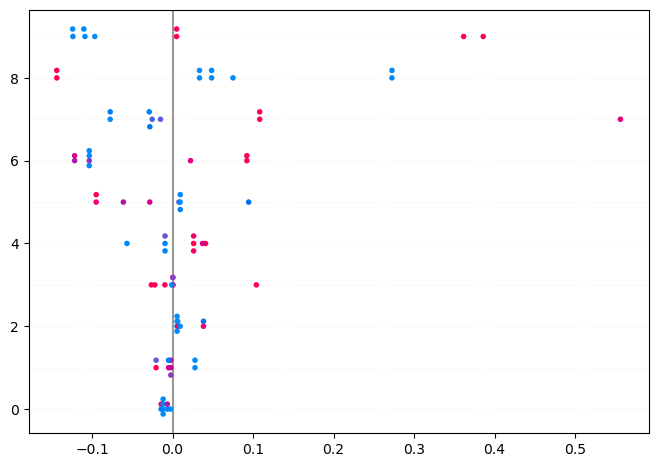

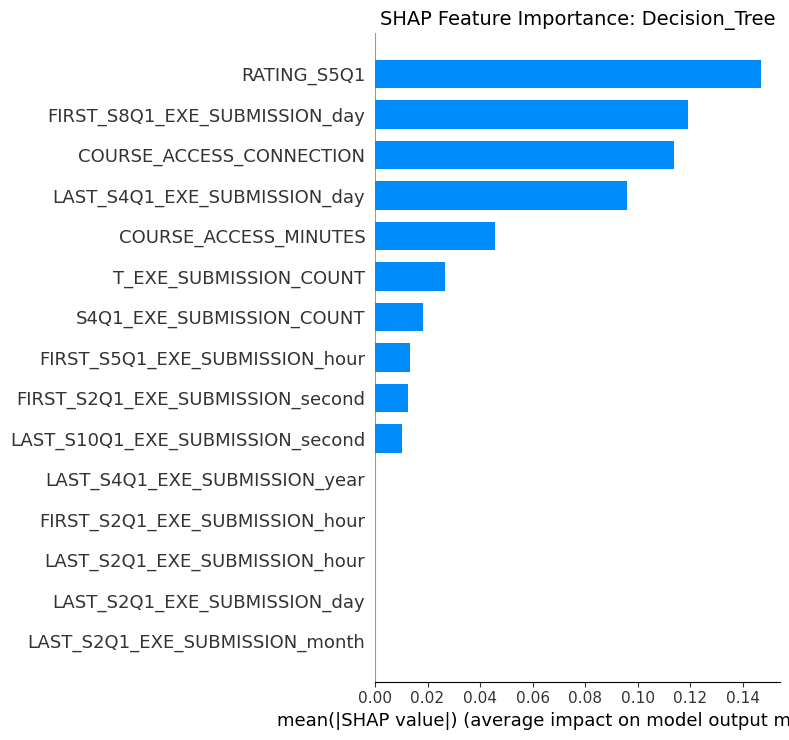

Waterfall Plots...


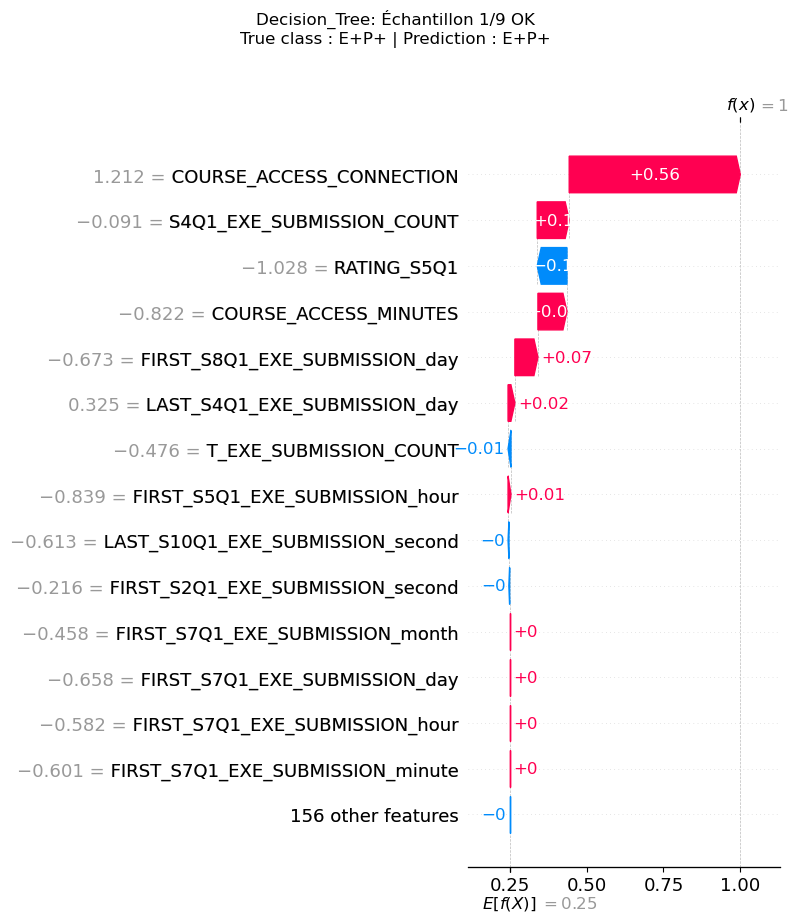

   Échantillon 1 : True=E+P+ | Predicted=E+P+ OK


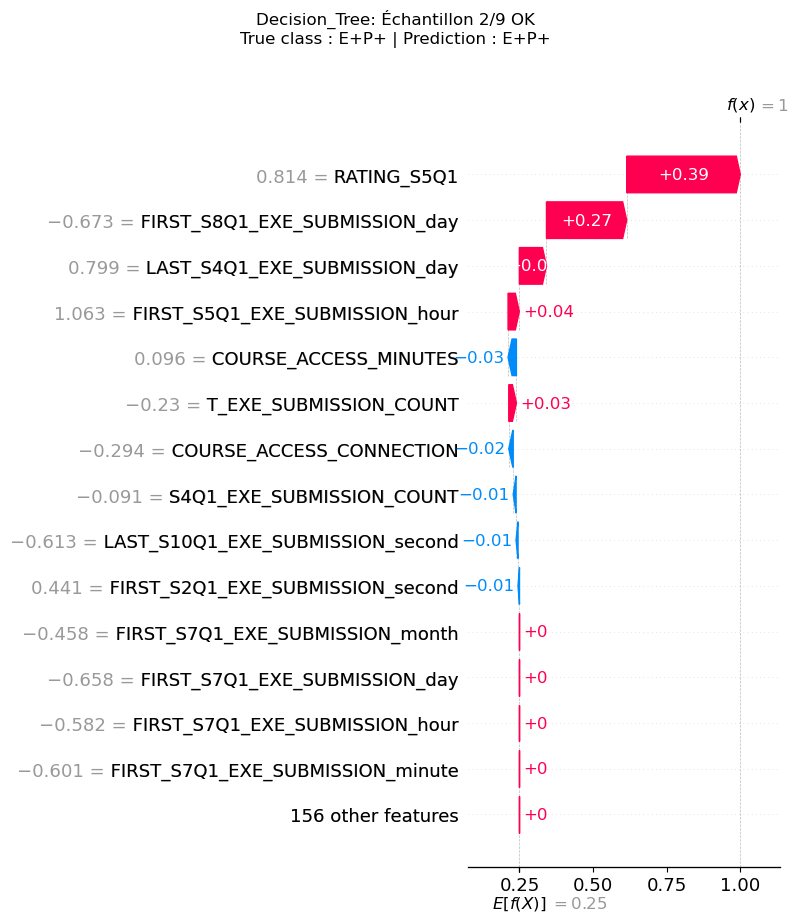

   Échantillon 2 : True=E+P+ | Predicted=E+P+ OK


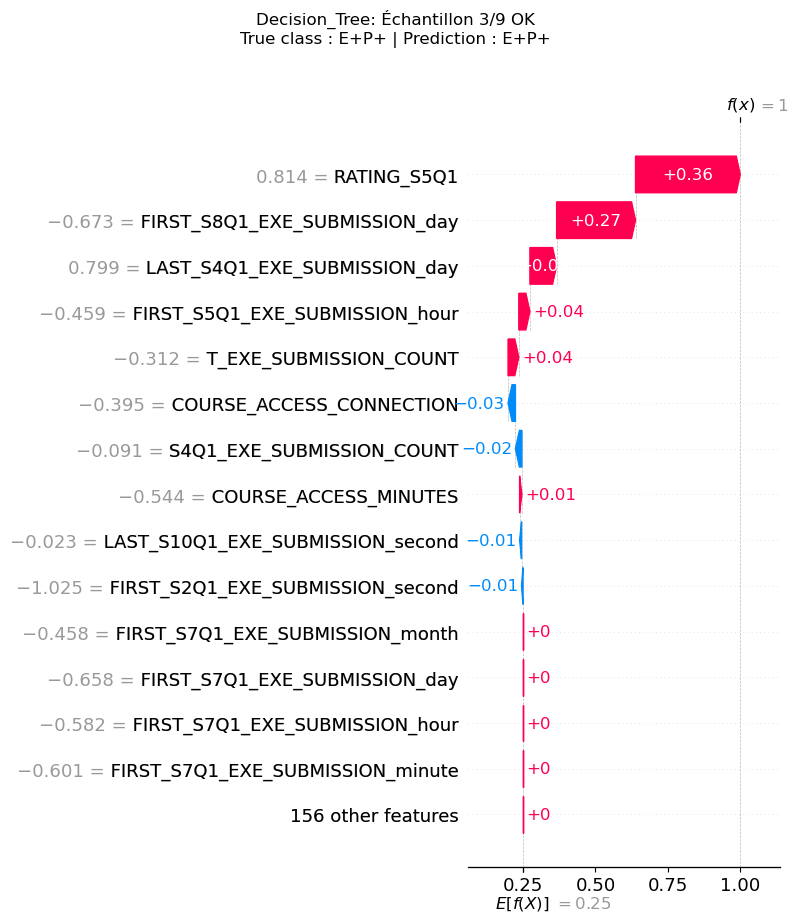

   Échantillon 3 : True=E+P+ | Predicted=E+P+ OK


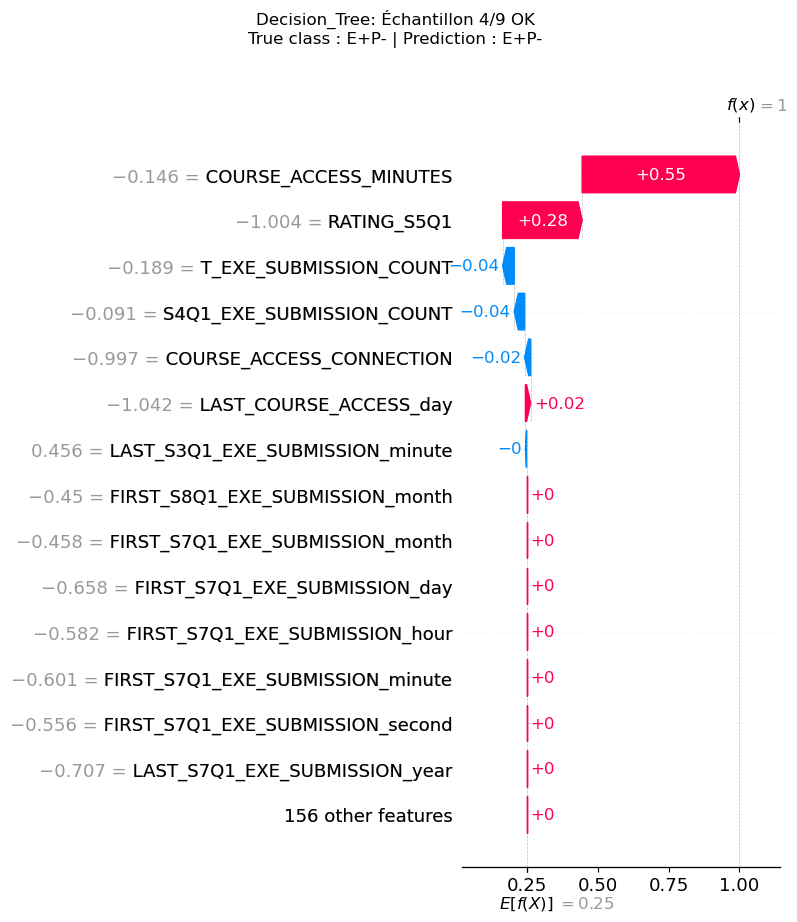

   Échantillon 4 : True=E+P- | Predicted=E+P- OK


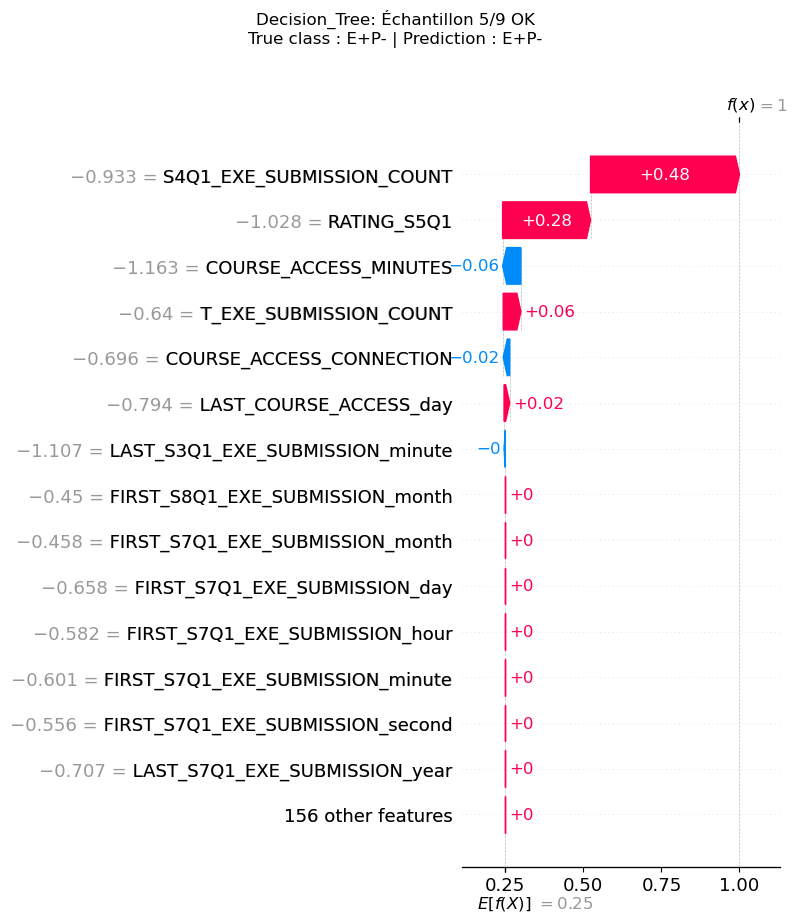

   Échantillon 5 : True=E+P- | Predicted=E+P- OK


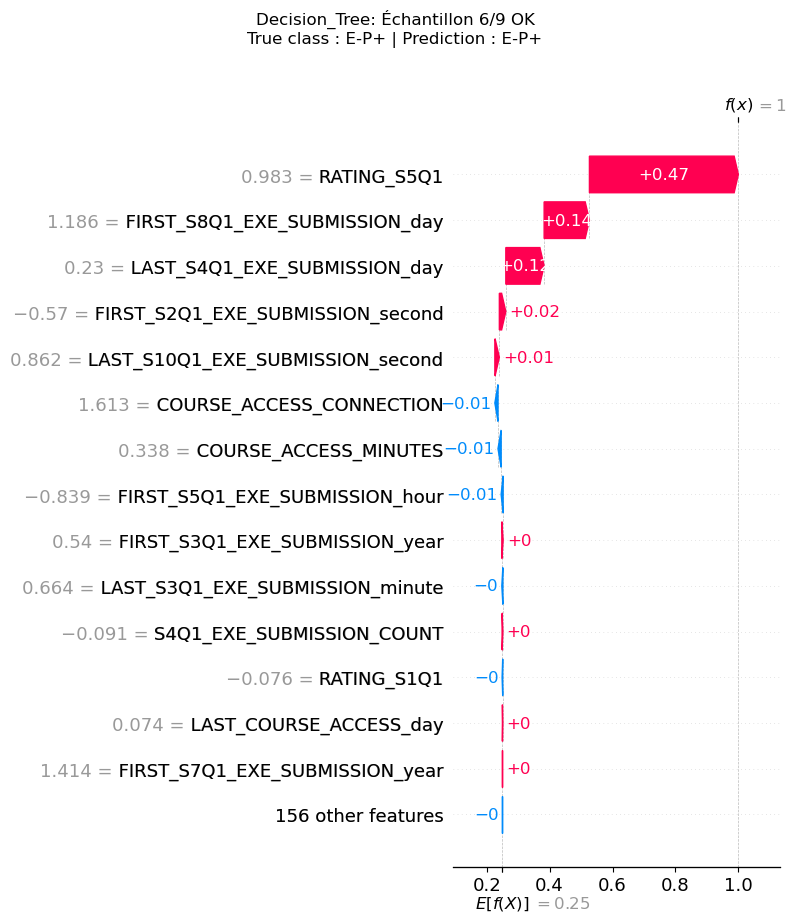

   Échantillon 6 : True=E-P+ | Predicted=E-P+ OK


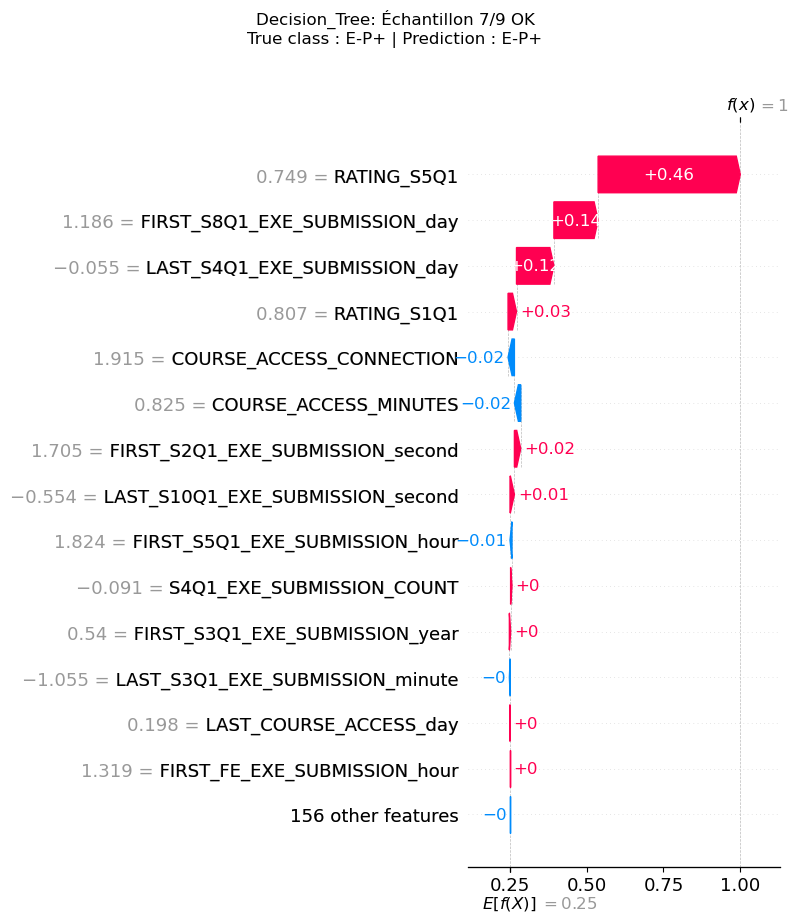

   Échantillon 7 : True=E-P+ | Predicted=E-P+ OK


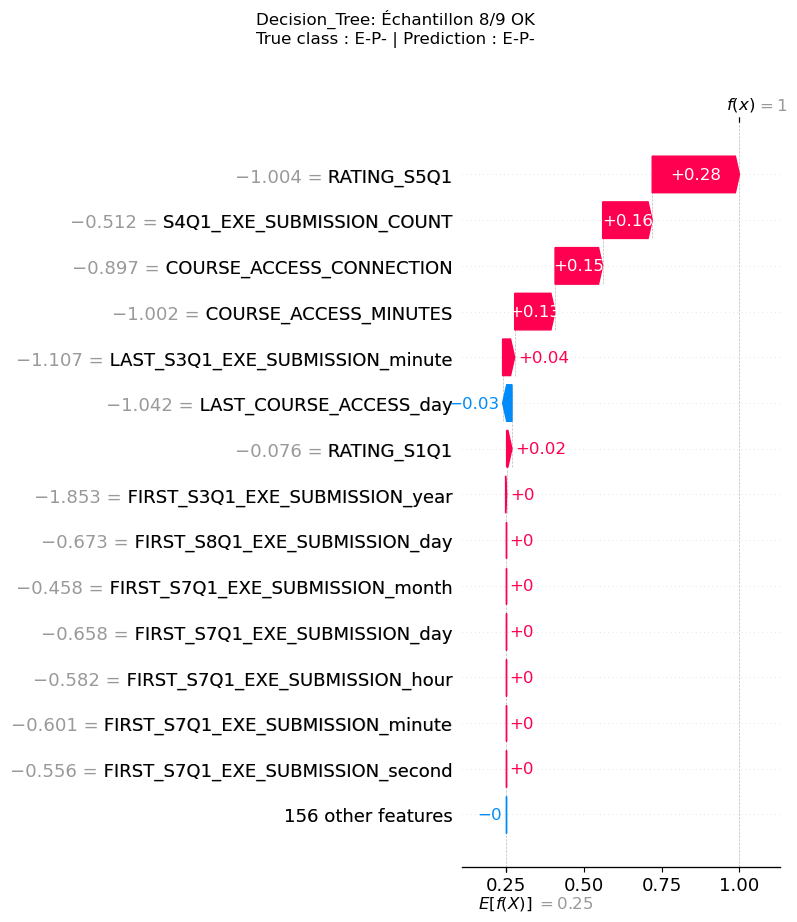

   Échantillon 8 : True=E-P- | Predicted=E-P- OK


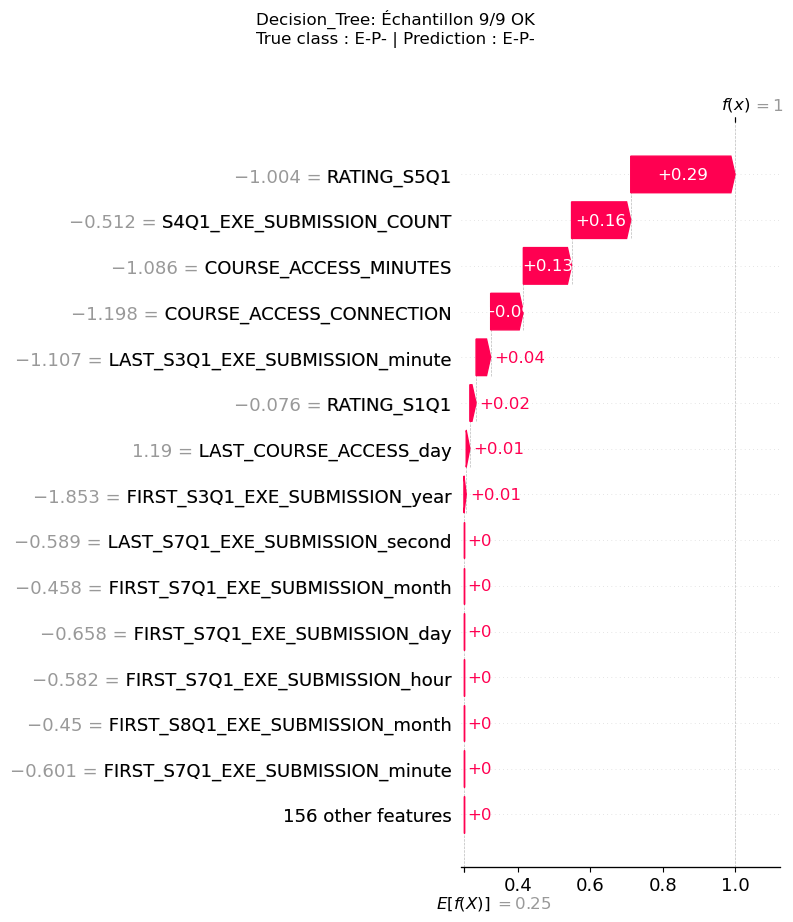

   Échantillon 9 : True=E-P- | Predicted=E-P- OK

 SHAP PLOTS: Random_Forest
Summary Plot...
   Error in summary plot : Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
Bar Plot...


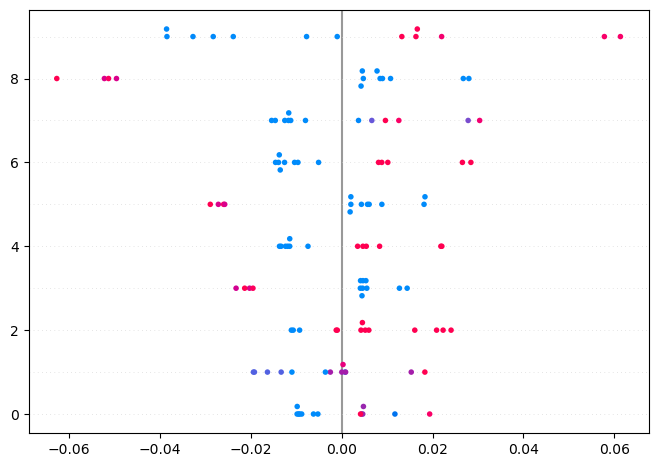

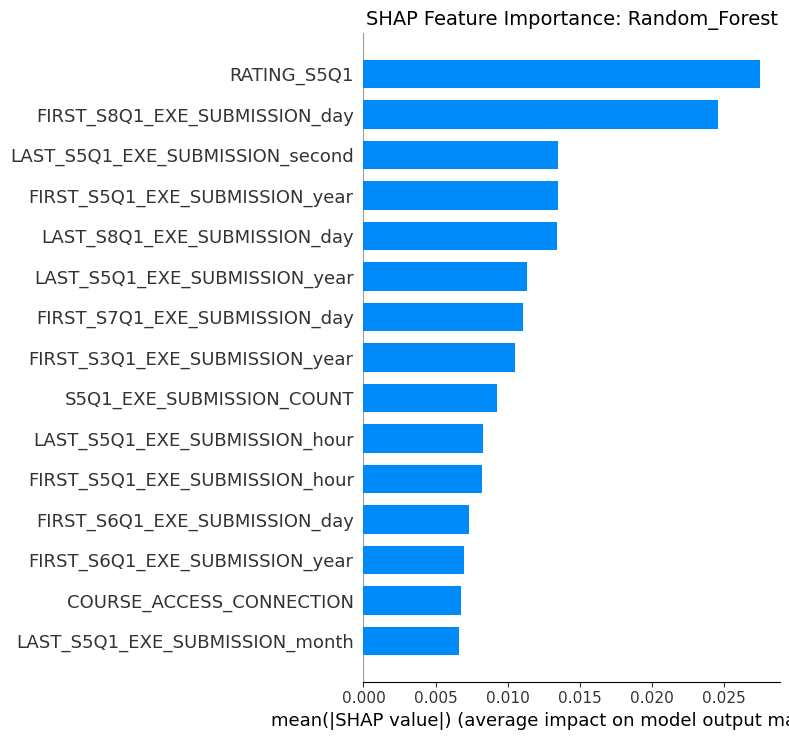

Waterfall Plots...


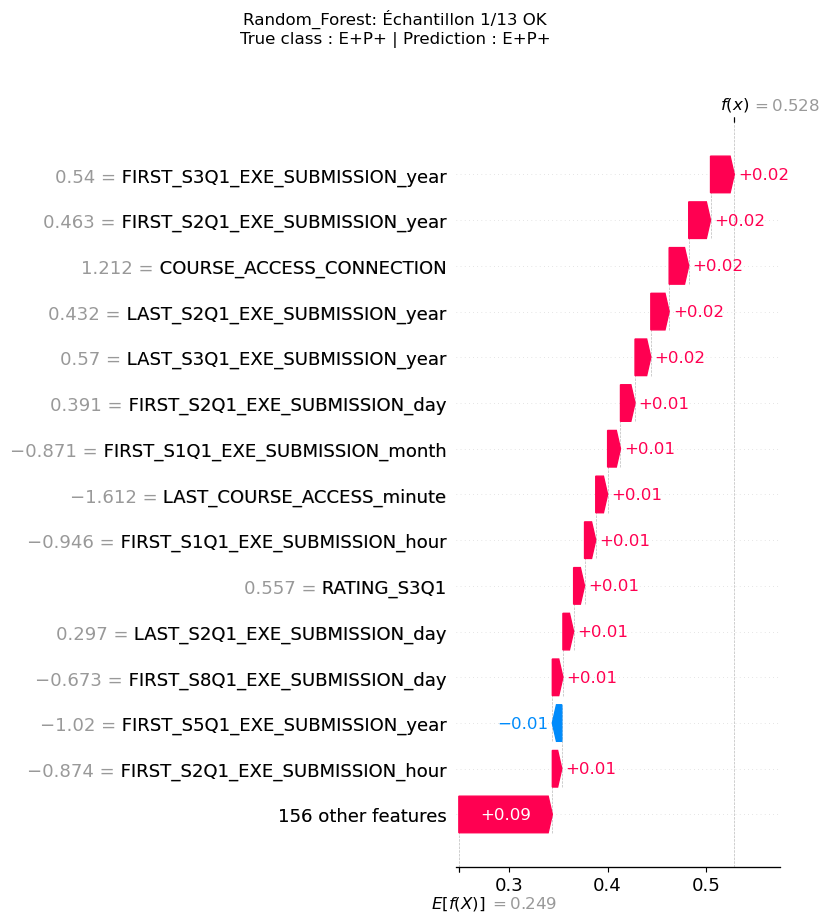

   Échantillon 1 : True=E+P+ | Predicted=E+P+ OK


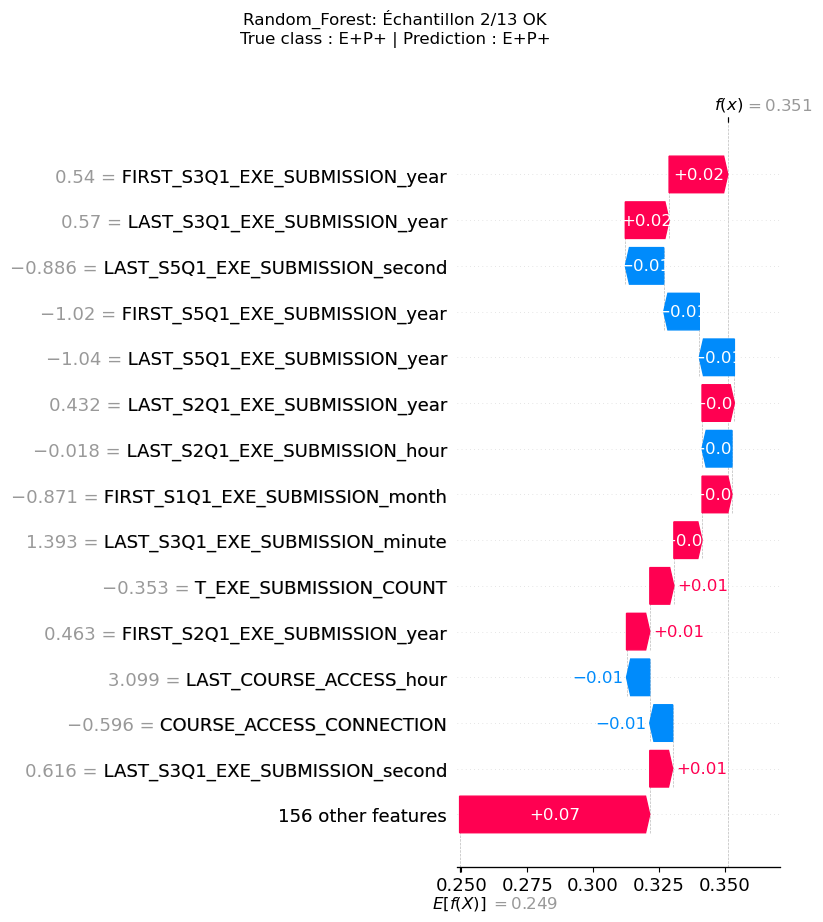

   Échantillon 2 : True=E+P+ | Predicted=E+P+ OK


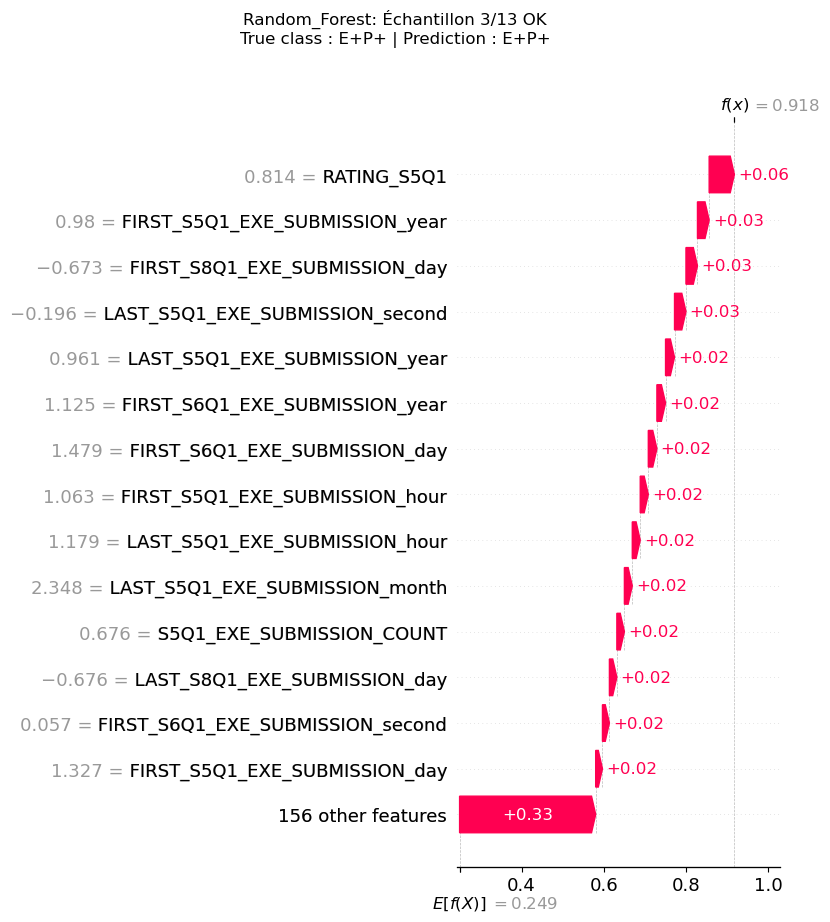

   Échantillon 3 : True=E+P+ | Predicted=E+P+ OK


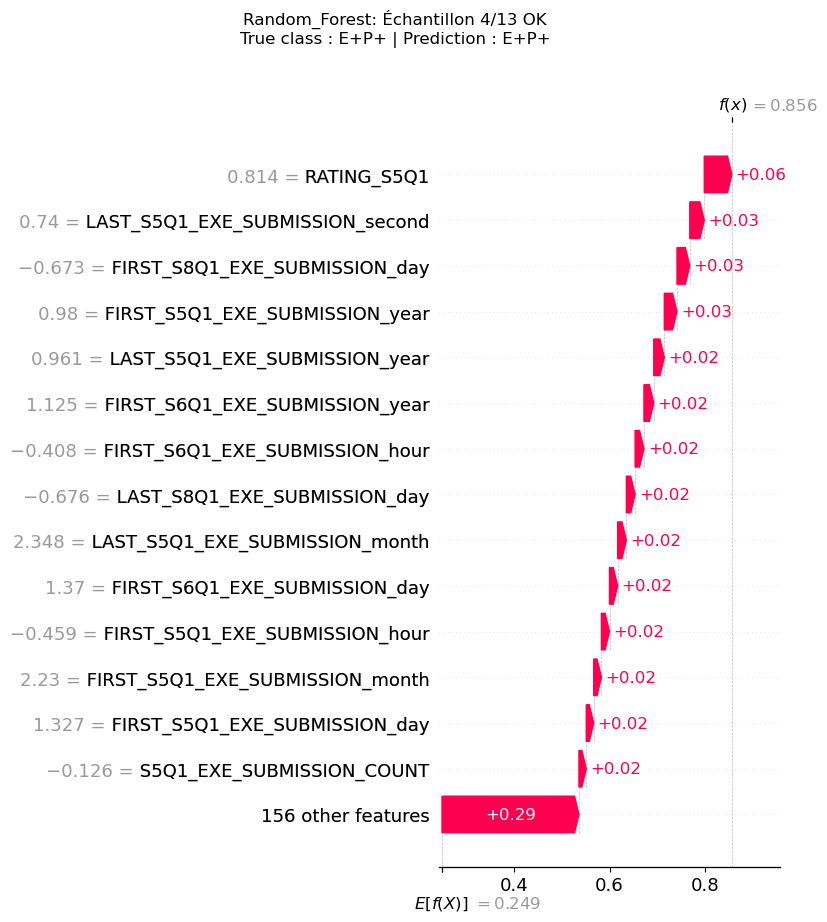

   Échantillon 4 : True=E+P+ | Predicted=E+P+ OK


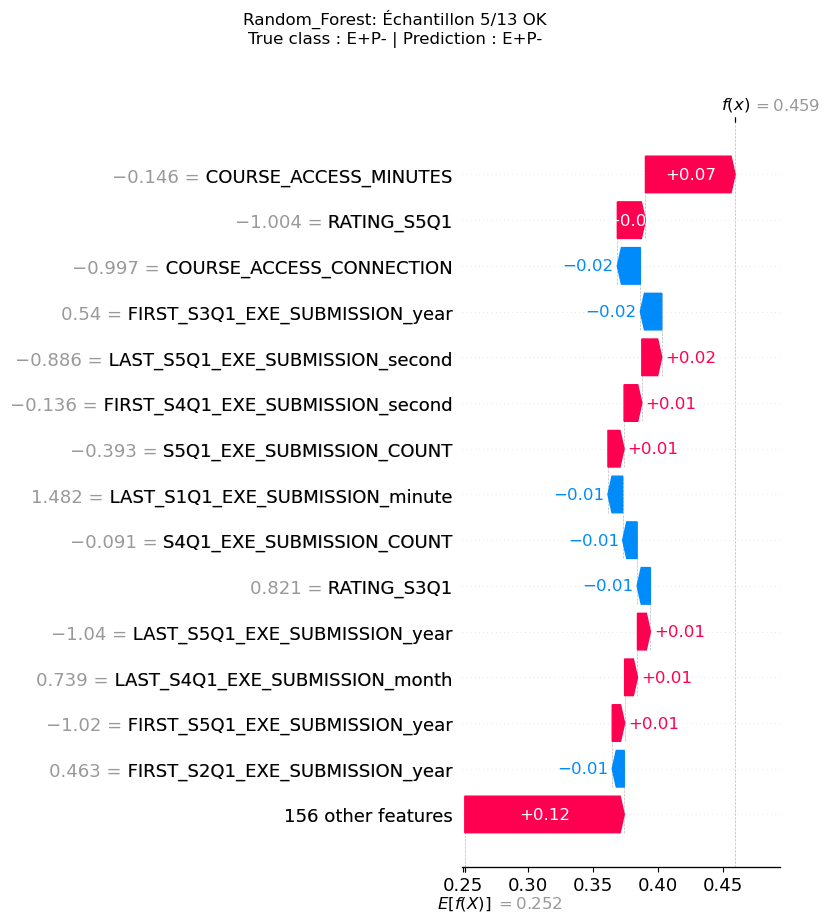

   Échantillon 5 : True=E+P- | Predicted=E+P- OK


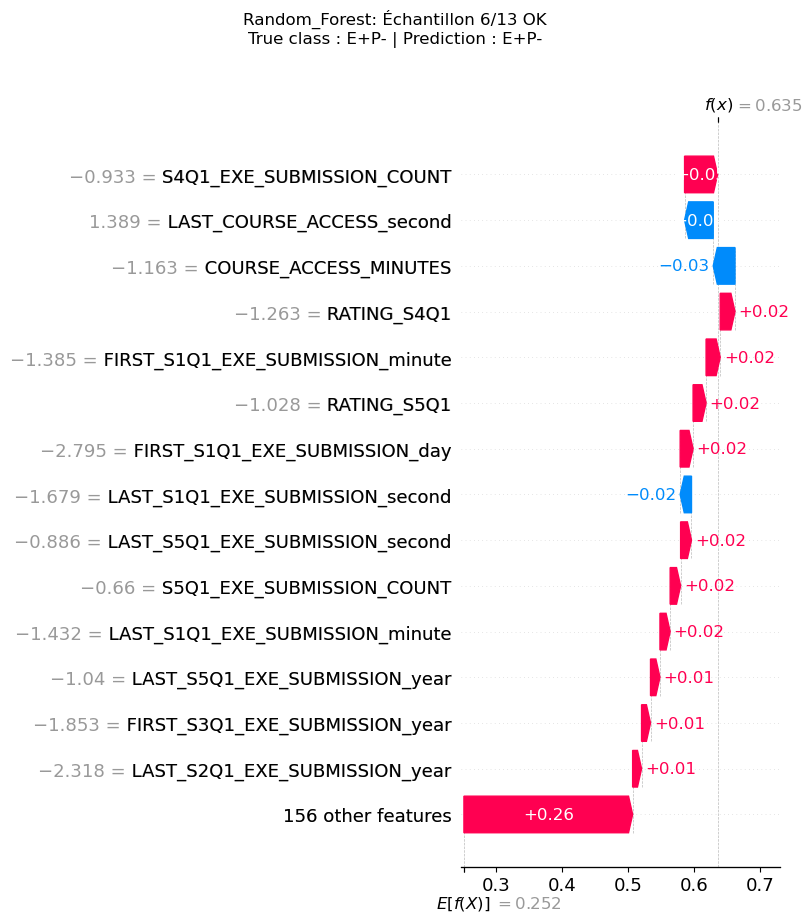

   Échantillon 6 : True=E+P- | Predicted=E+P- OK


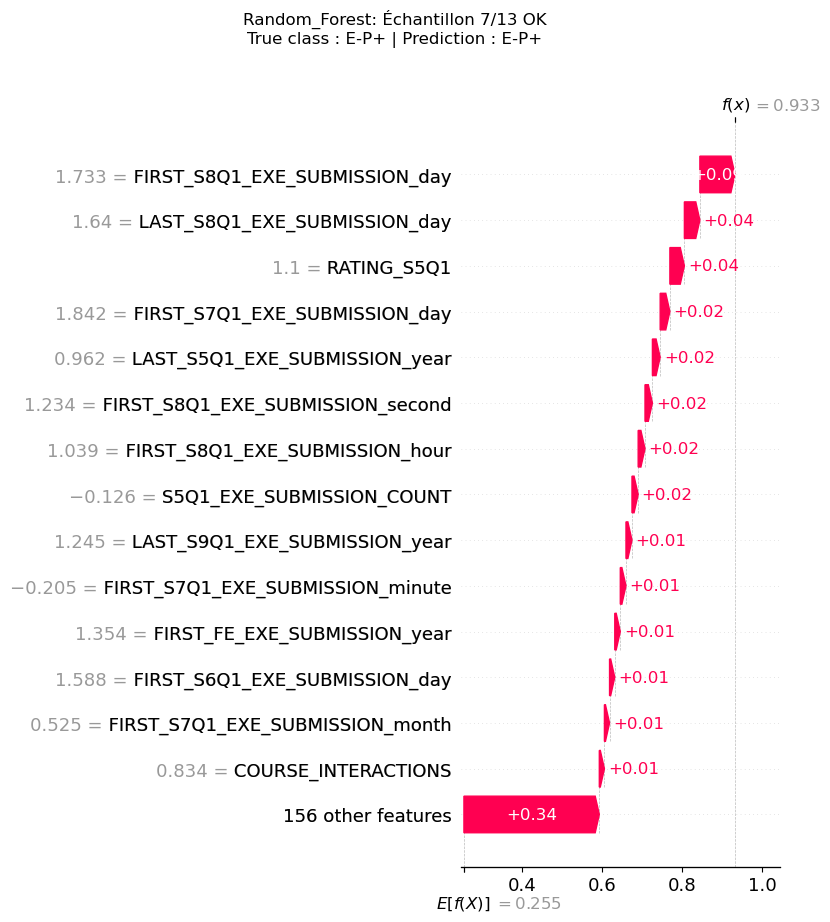

   Échantillon 7 : True=E-P+ | Predicted=E-P+ OK


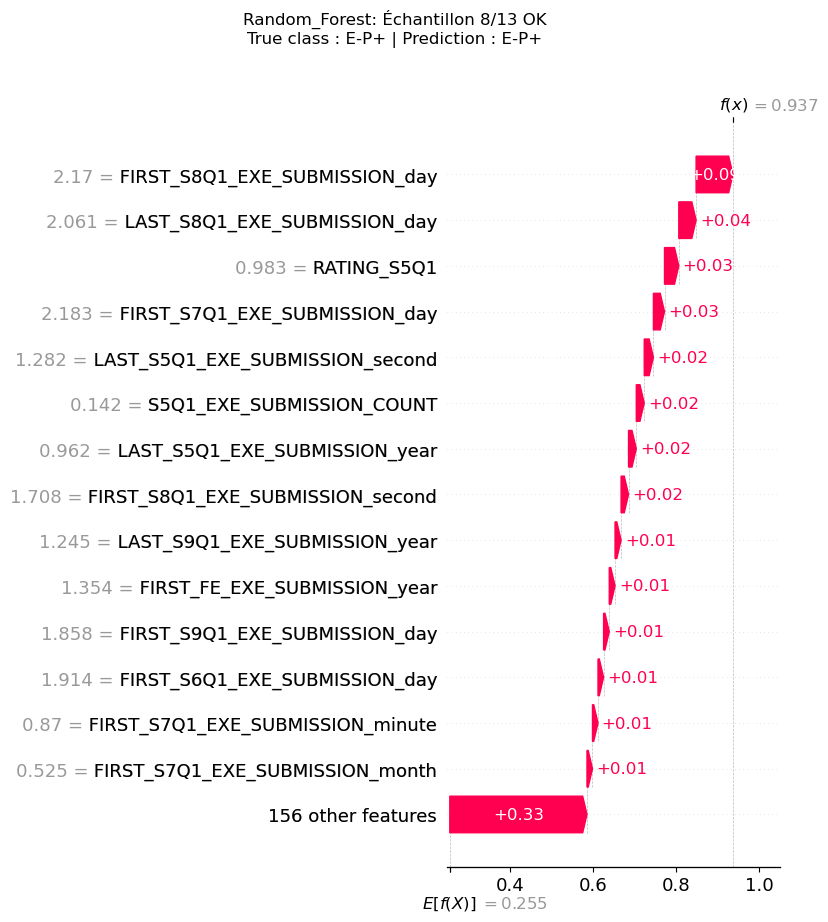

   Échantillon 8 : True=E-P+ | Predicted=E-P+ OK


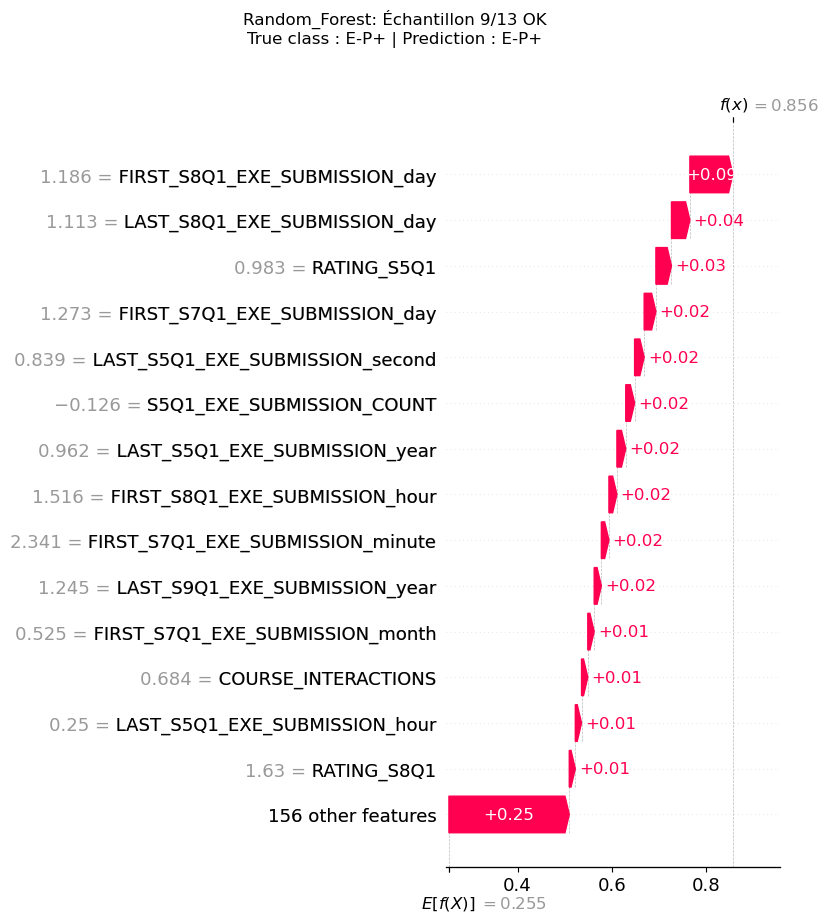

   Échantillon 9 : True=E-P+ | Predicted=E-P+ OK


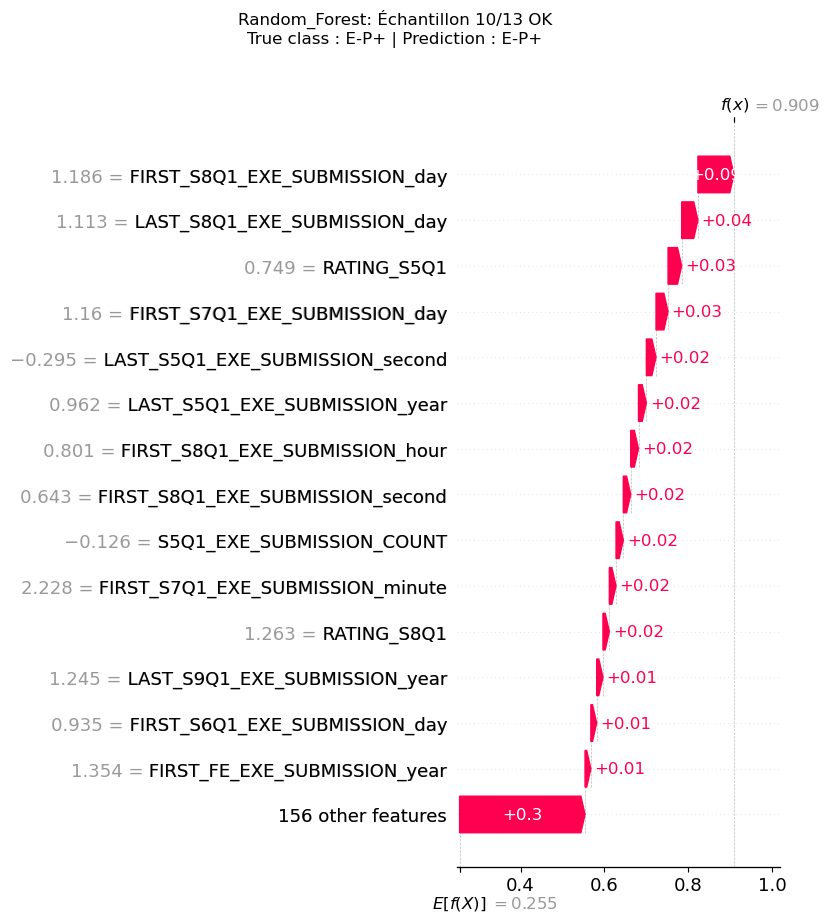

   Échantillon 10 : True=E-P+ | Predicted=E-P+ OK


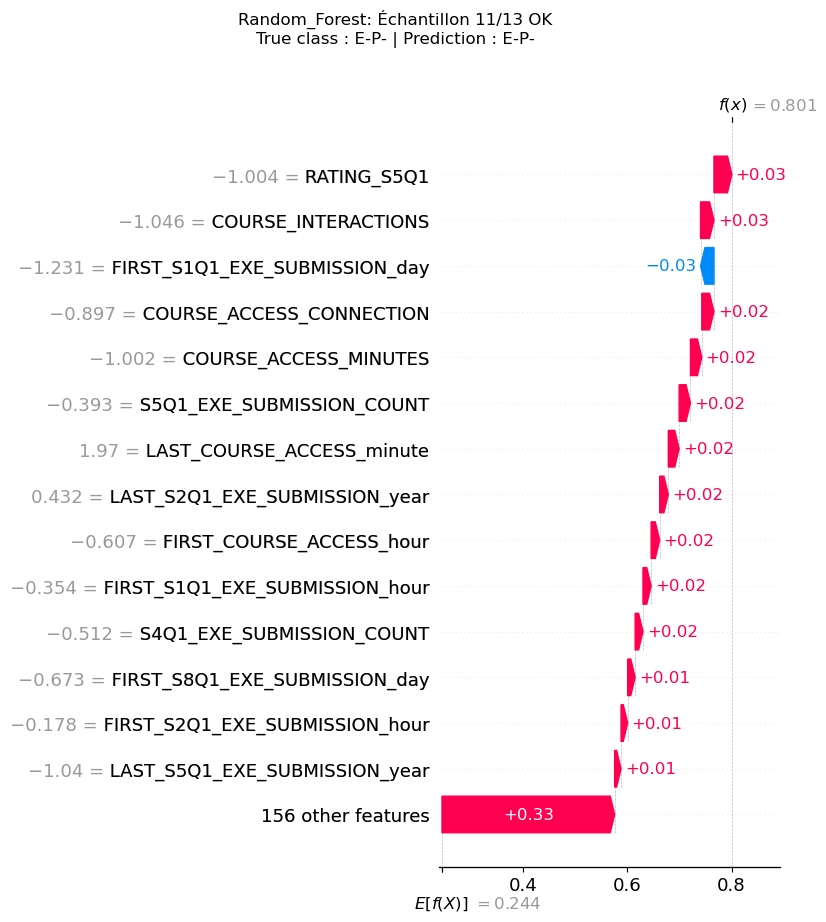

   Échantillon 11 : True=E-P- | Predicted=E-P- OK


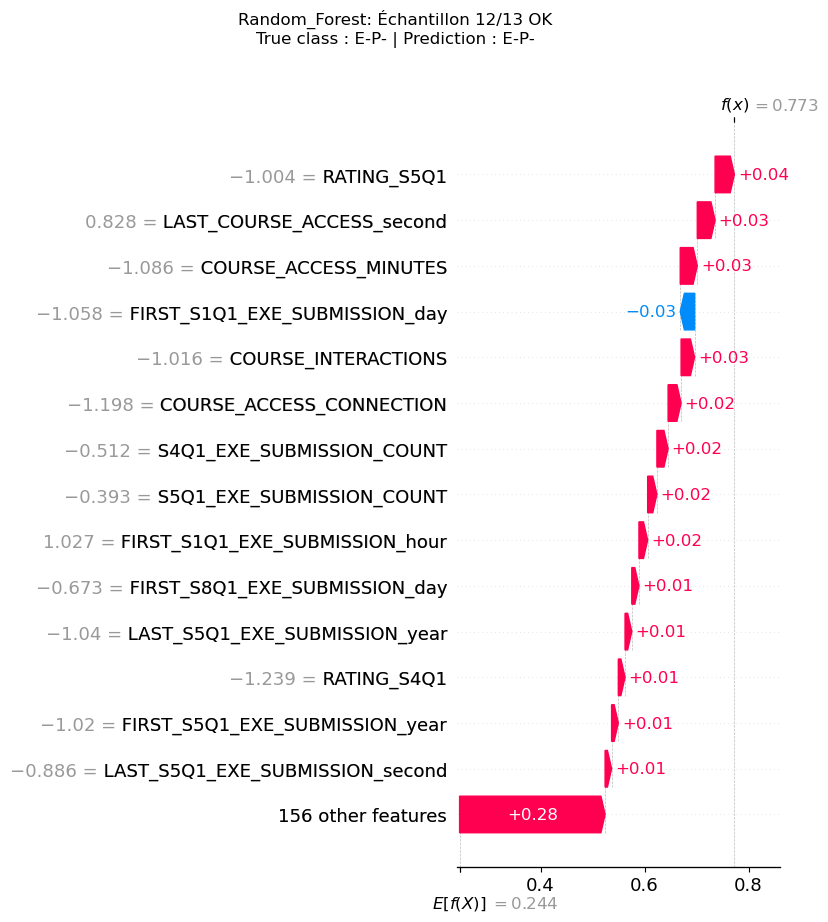

   Échantillon 12 : True=E-P- | Predicted=E-P- OK


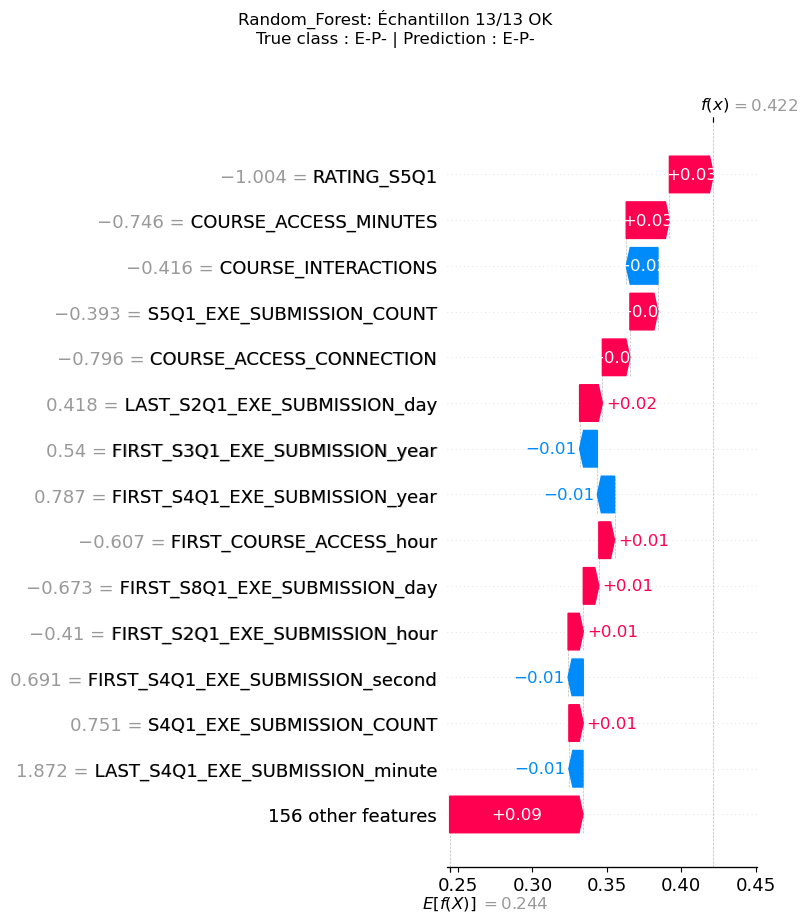

   Échantillon 13 : True=E-P- | Predicted=E-P- OK

 SHAP PLOTS: XGBoost
Summary Plot...
   Error in summary plot : Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
Bar Plot...


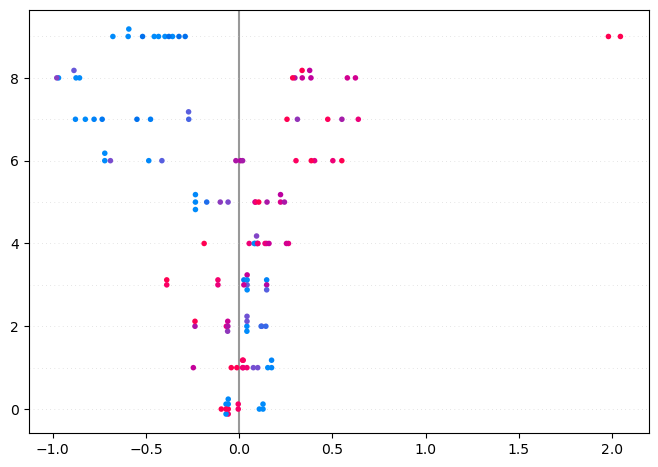

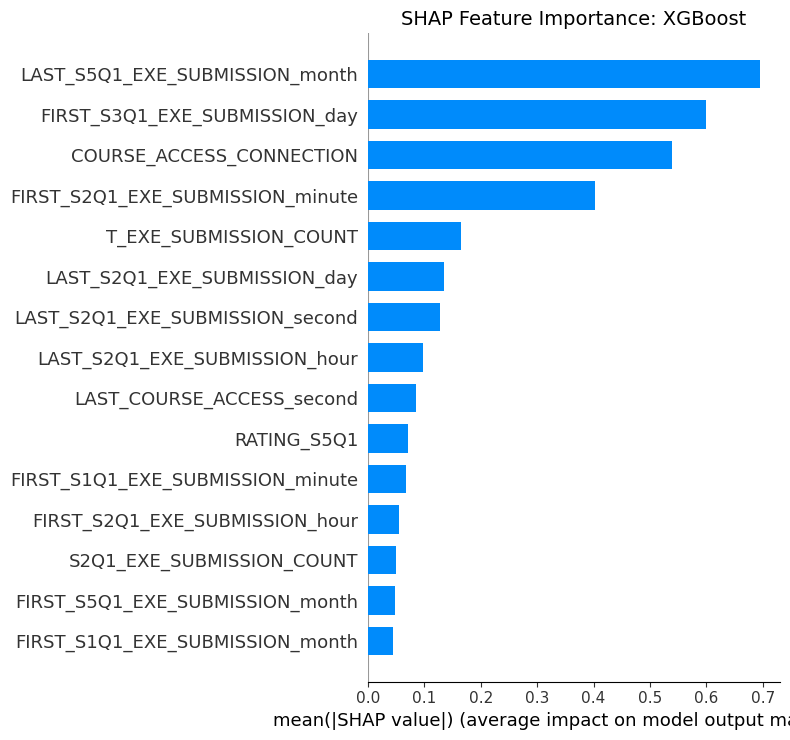

Waterfall Plots...


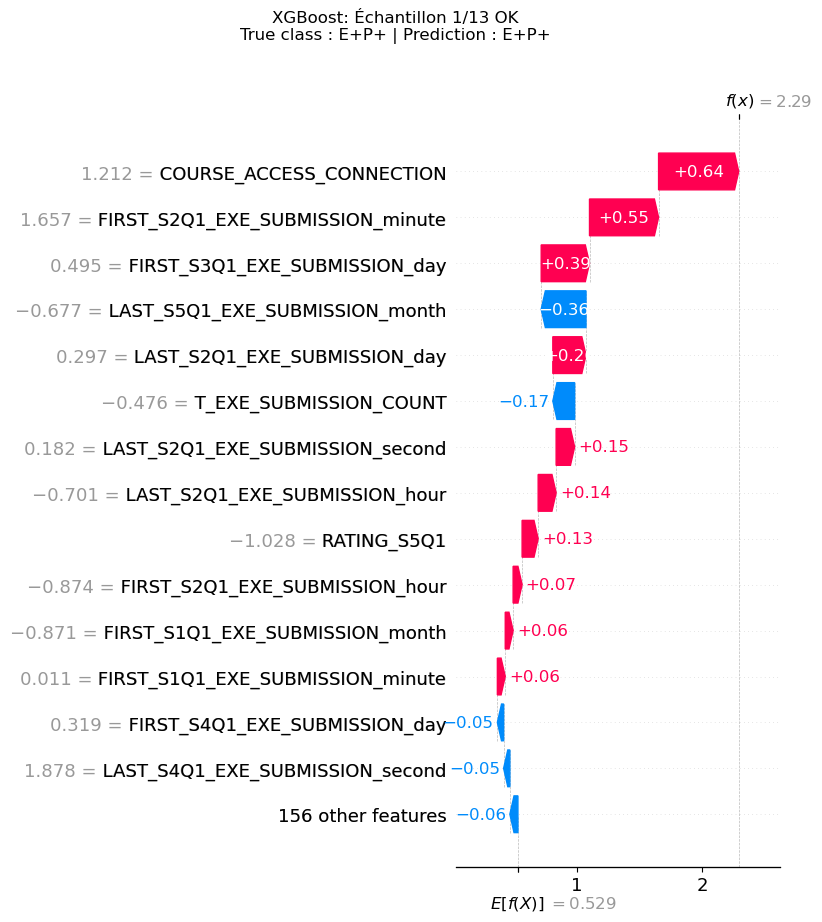

   Échantillon 1 : True=E+P+ | Predicted=E+P+ OK


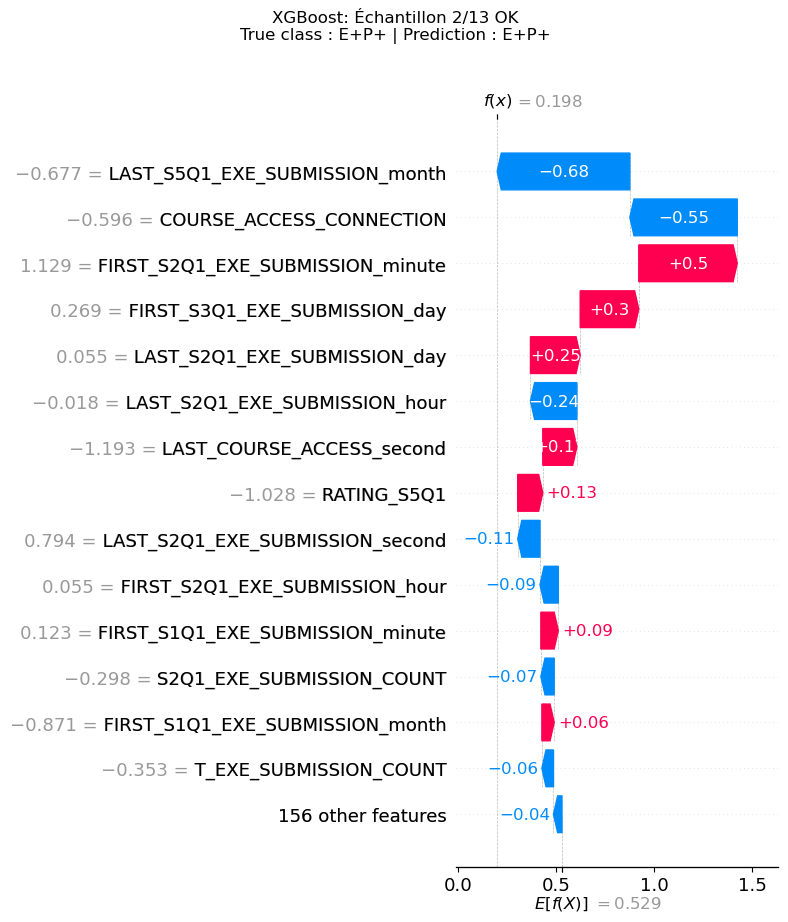

   Échantillon 2 : True=E+P+ | Predicted=E+P+ OK


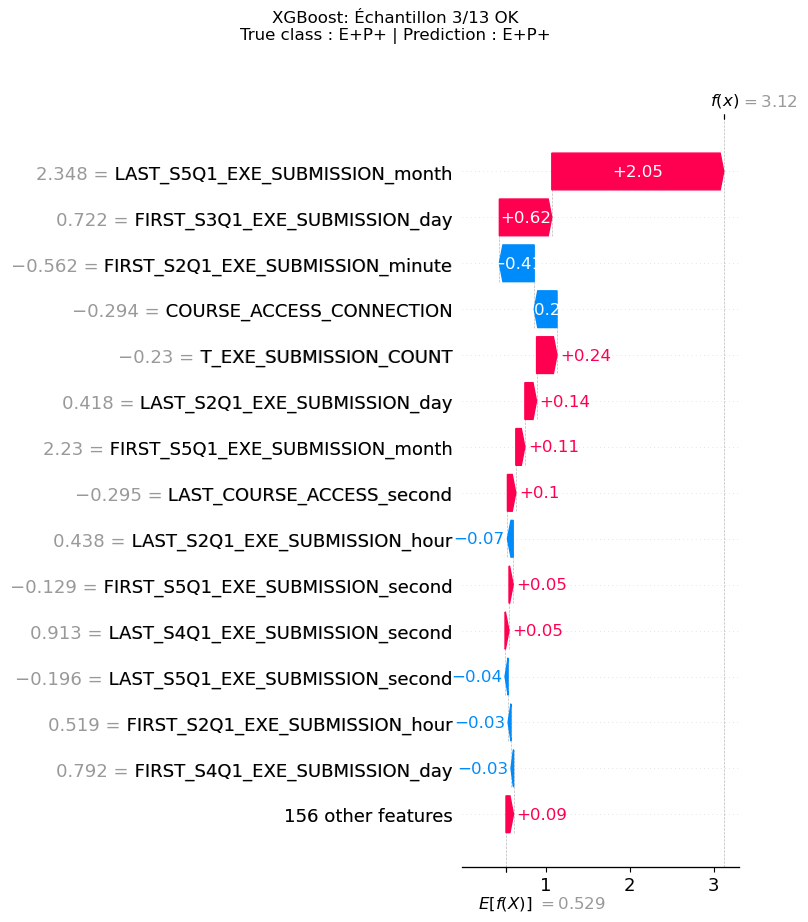

   Échantillon 3 : True=E+P+ | Predicted=E+P+ OK


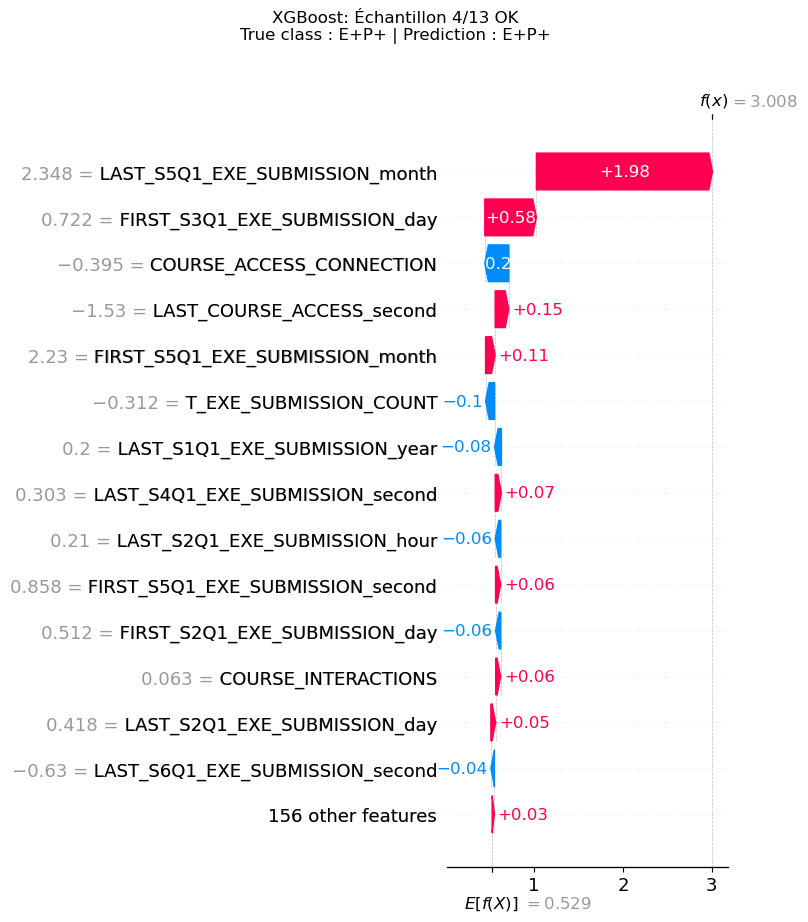

   Échantillon 4 : True=E+P+ | Predicted=E+P+ OK


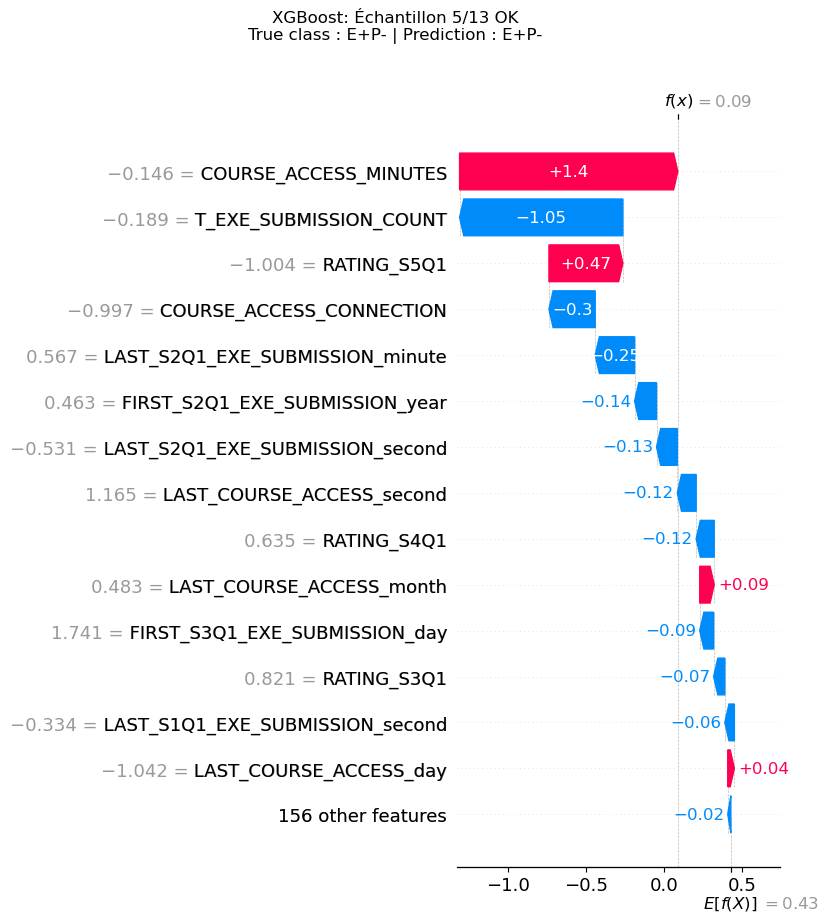

   Échantillon 5 : True=E+P- | Predicted=E+P- OK


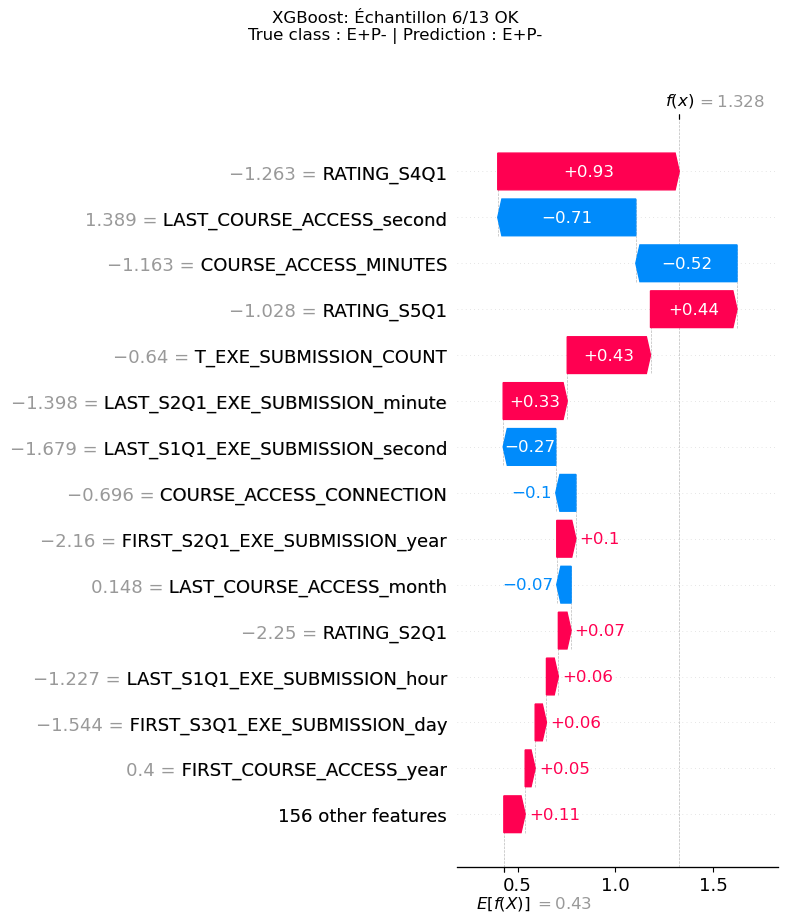

   Échantillon 6 : True=E+P- | Predicted=E+P- OK


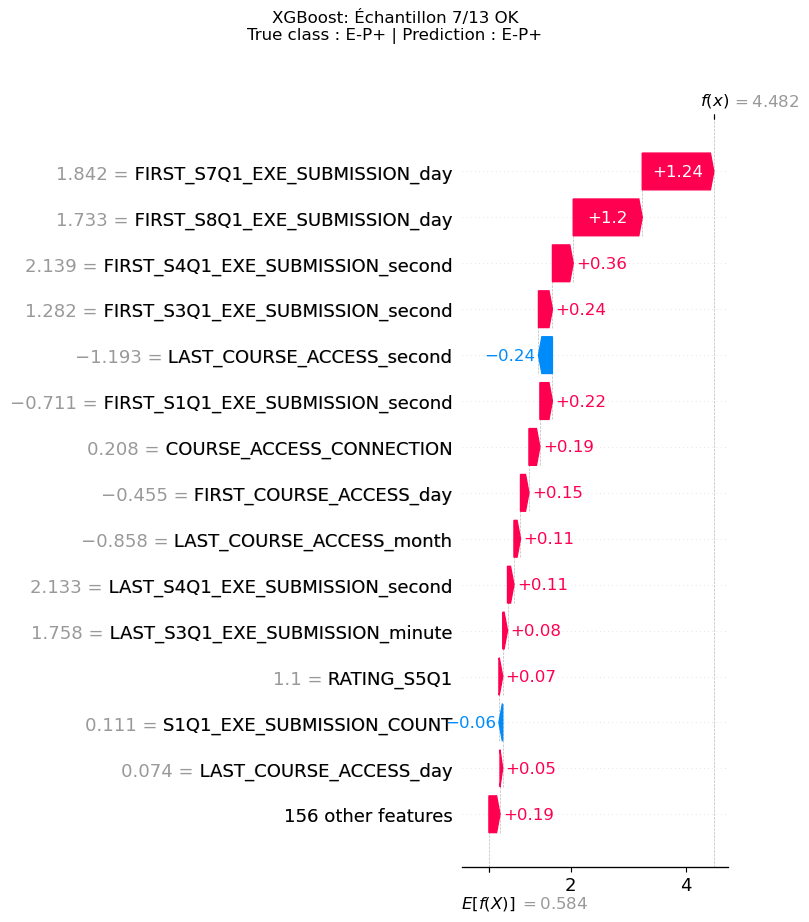

   Échantillon 7 : True=E-P+ | Predicted=E-P+ OK


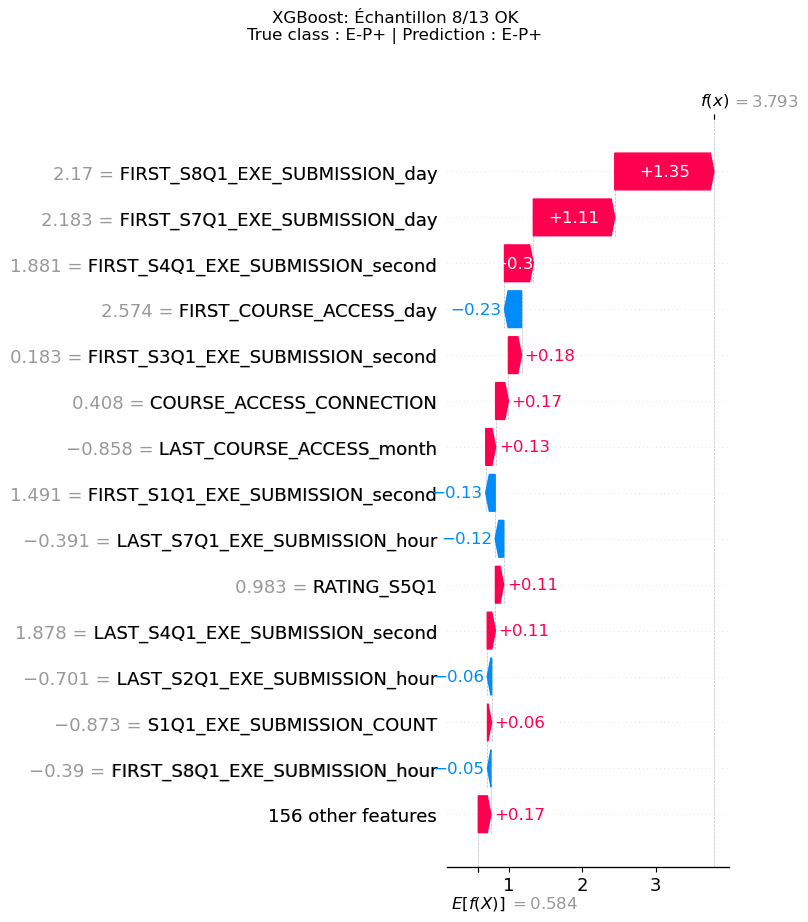

   Échantillon 8 : True=E-P+ | Predicted=E-P+ OK


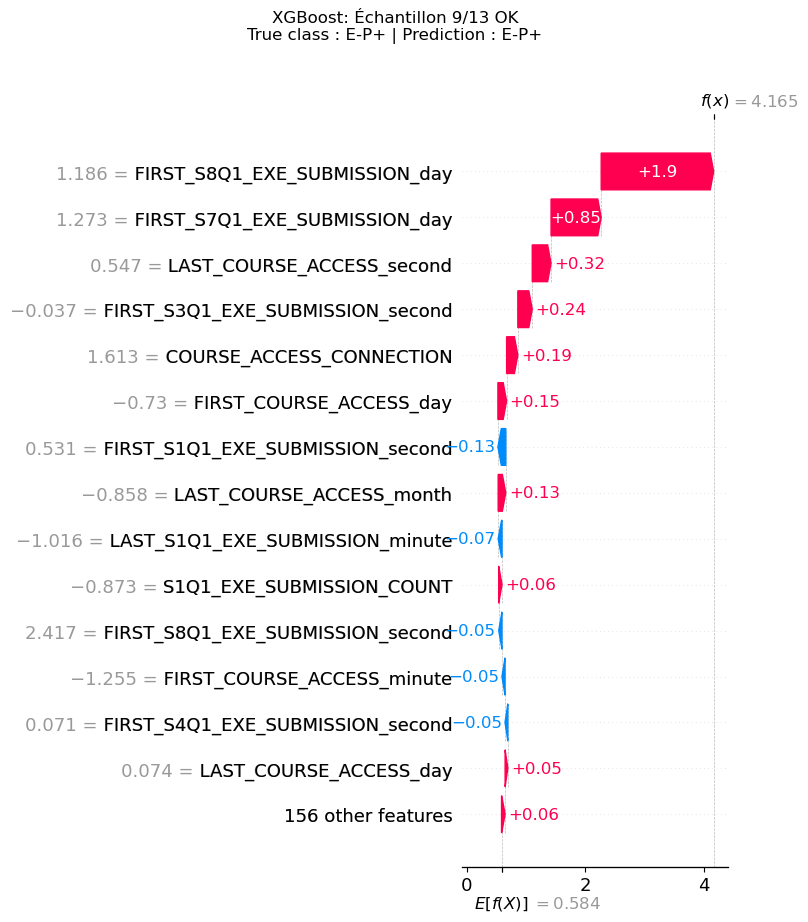

   Échantillon 9 : True=E-P+ | Predicted=E-P+ OK


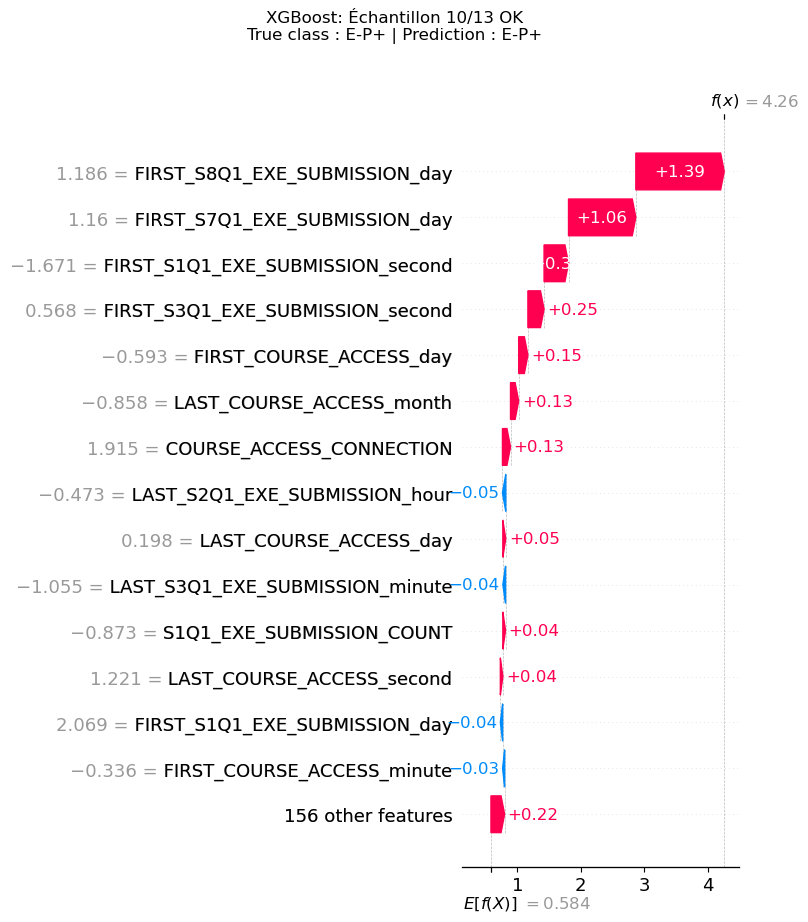

   Échantillon 10 : True=E-P+ | Predicted=E-P+ OK


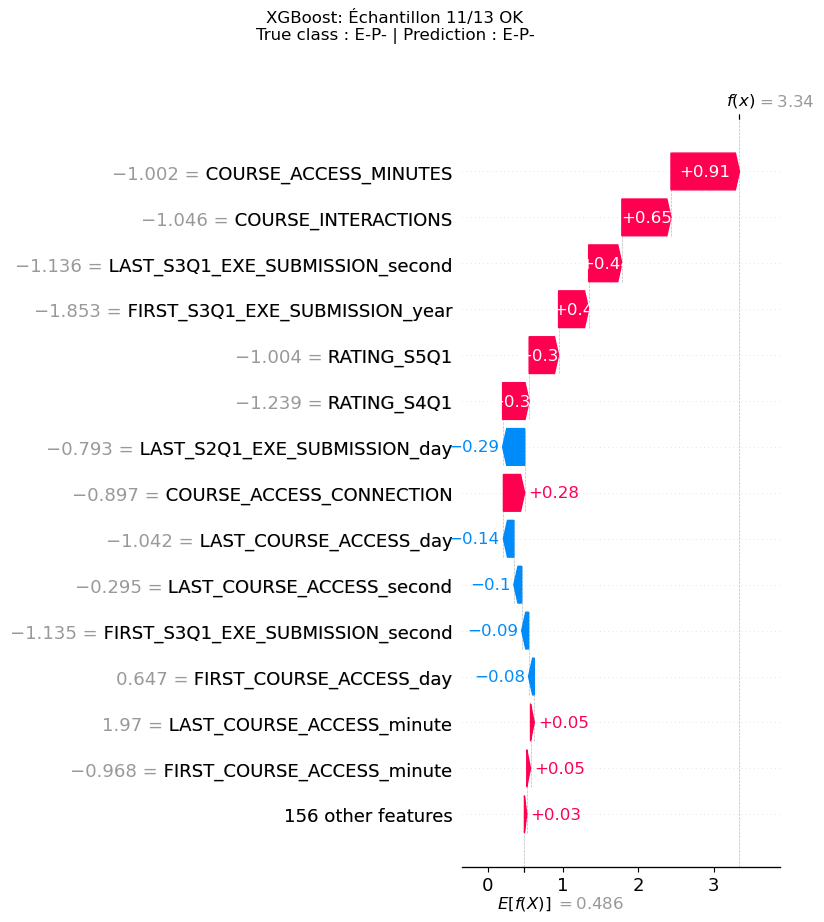

   Échantillon 11 : True=E-P- | Predicted=E-P- OK


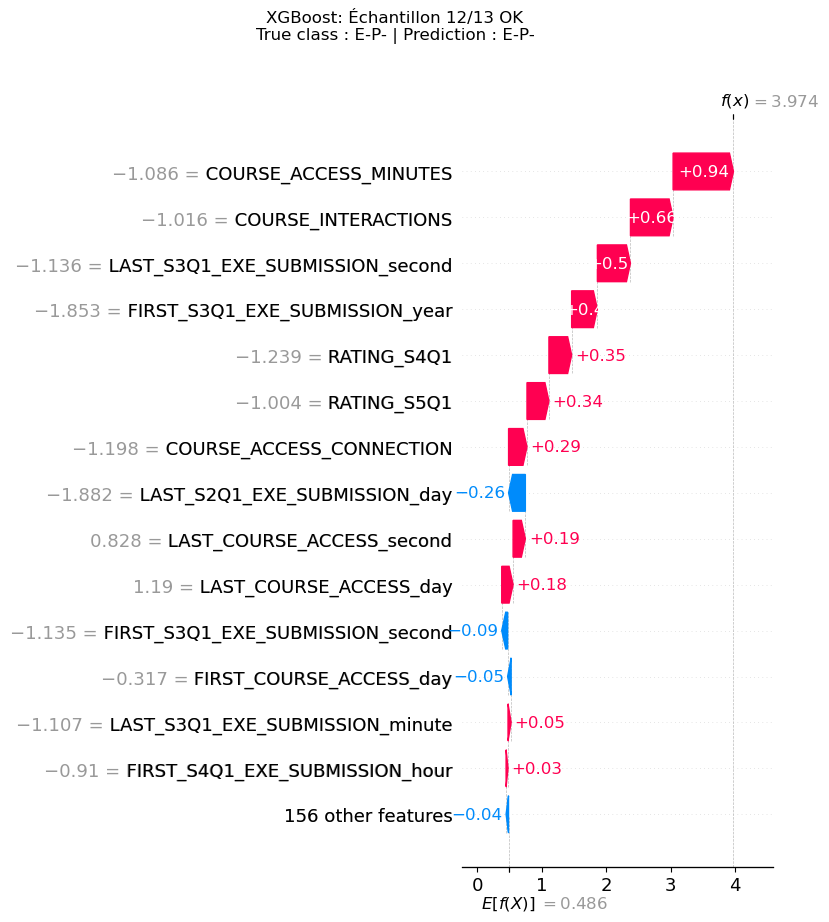

   Échantillon 12 : True=E-P- | Predicted=E-P- OK


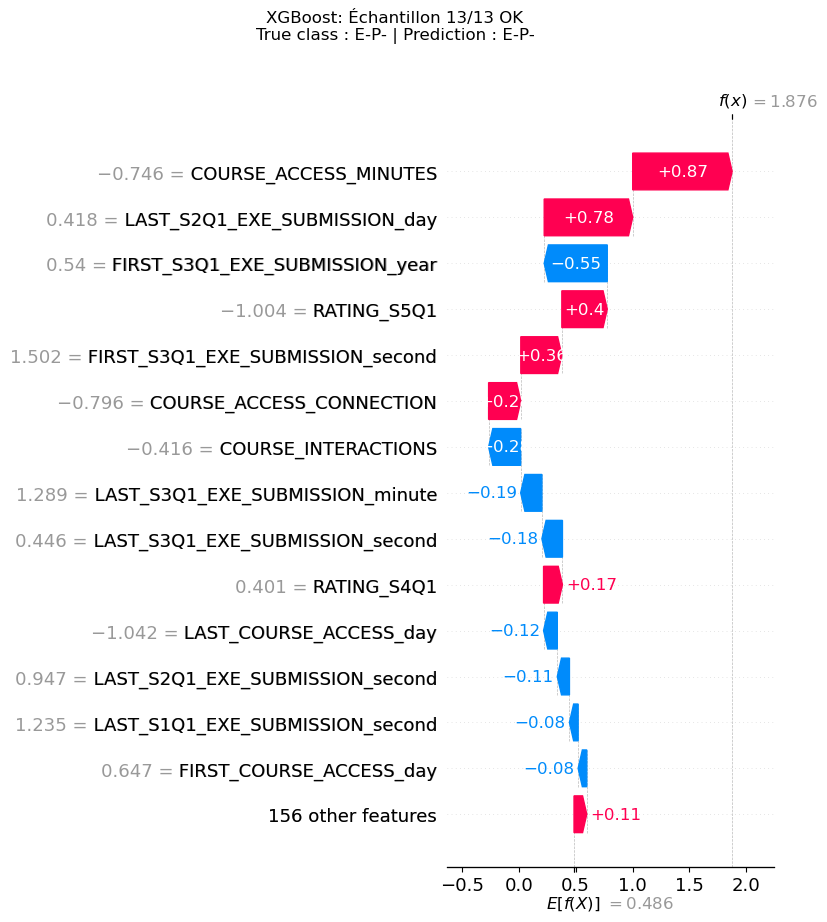

   Échantillon 13 : True=E-P- | Predicted=E-P- OK

 SHAP COMPARISON ACROSS MODELS

   Heatmap de comparaison...


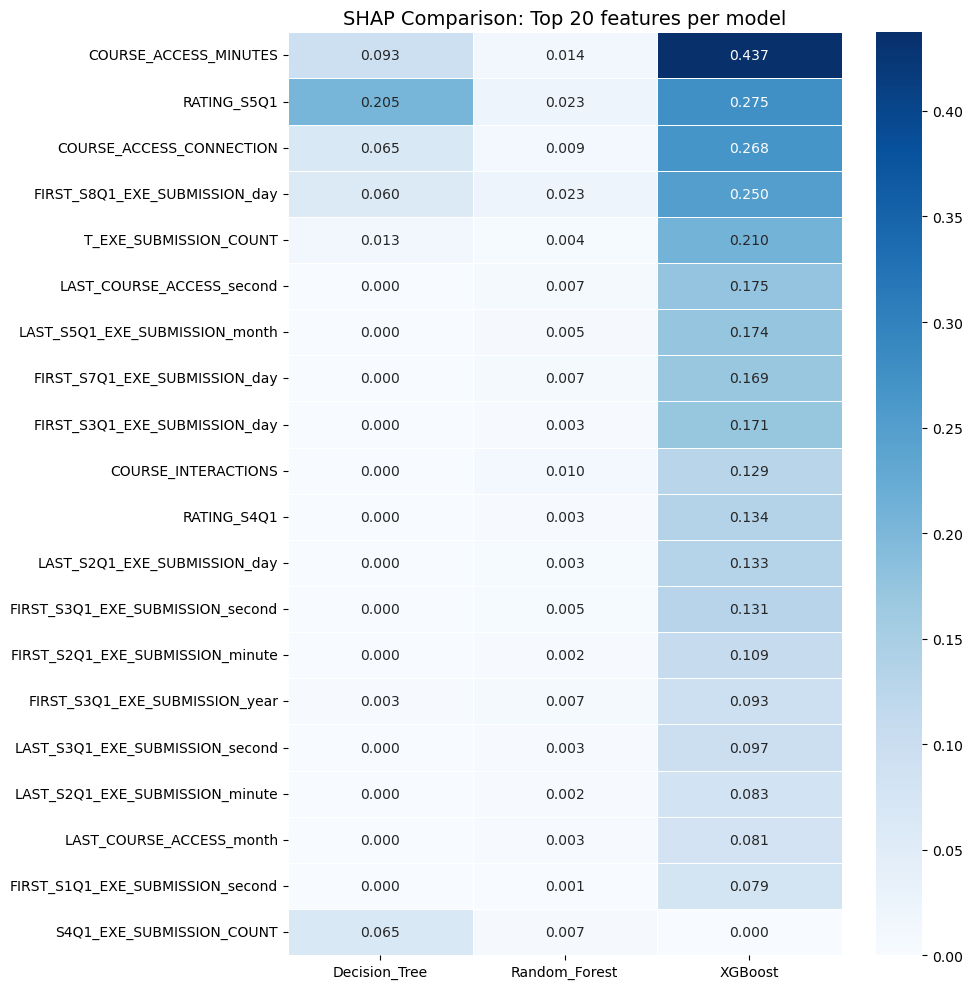


   Top 10 features (moyenne tous modèles)...


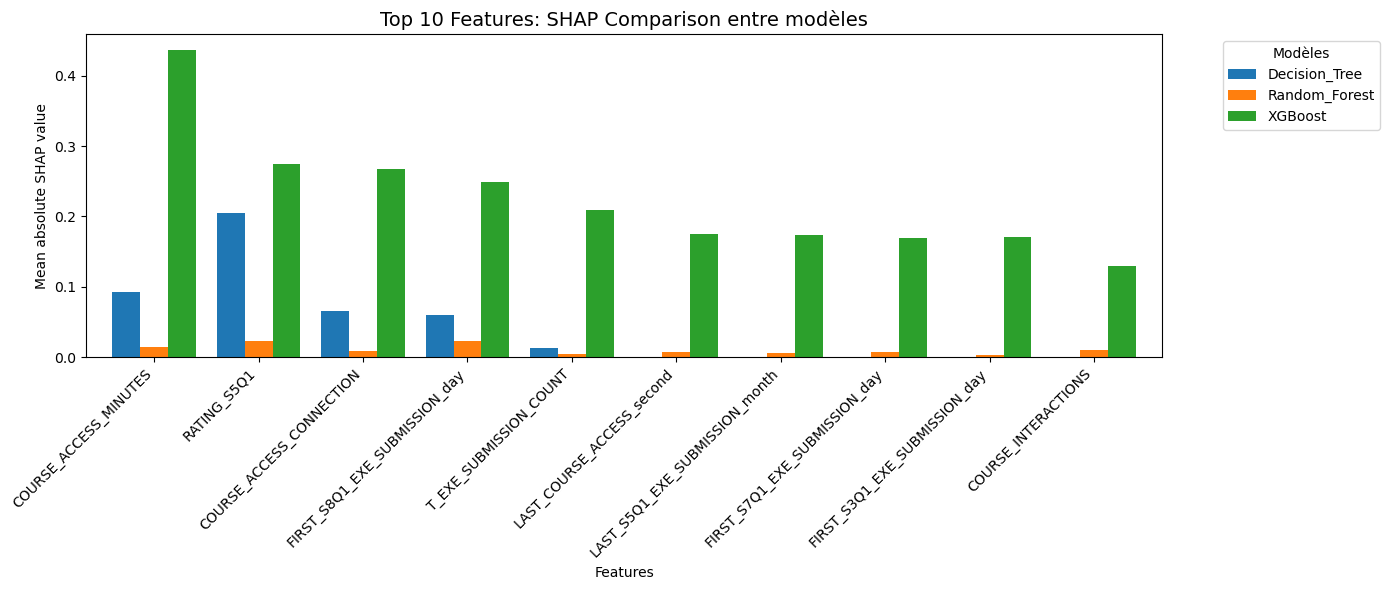


   SUMMARY: Top 5 features par modèle :

   Decision_Tree :
      RATING_S5Q1                              : 0.2055
      COURSE_ACCESS_MINUTES                    : 0.0930
      COURSE_ACCESS_CONNECTION                 : 0.0655
      S4Q1_EXE_SUBMISSION_COUNT                : 0.0654
      FIRST_S8Q1_EXE_SUBMISSION_day            : 0.0595

   Random_Forest :
      RATING_S5Q1                              : 0.0228
      FIRST_S8Q1_EXE_SUBMISSION_day            : 0.0228
      COURSE_ACCESS_MINUTES                    : 0.0143
      LAST_S5Q1_EXE_SUBMISSION_second          : 0.0124
      LAST_S8Q1_EXE_SUBMISSION_day             : 0.0119

   XGBoost :
      COURSE_ACCESS_MINUTES                    : 0.4373
      RATING_S5Q1                              : 0.2753
      COURSE_ACCESS_CONNECTION                 : 0.2677
      FIRST_S8Q1_EXE_SUBMISSION_day            : 0.2497
      T_EXE_SUBMISSION_COUNT                   : 0.2097

 COMPUTING STABILITY

   Modèle : Decision_Tree
Creating explain

In [9]:
shap_eval = SHAPEvaluator(evaluator)
shap_eval.run()

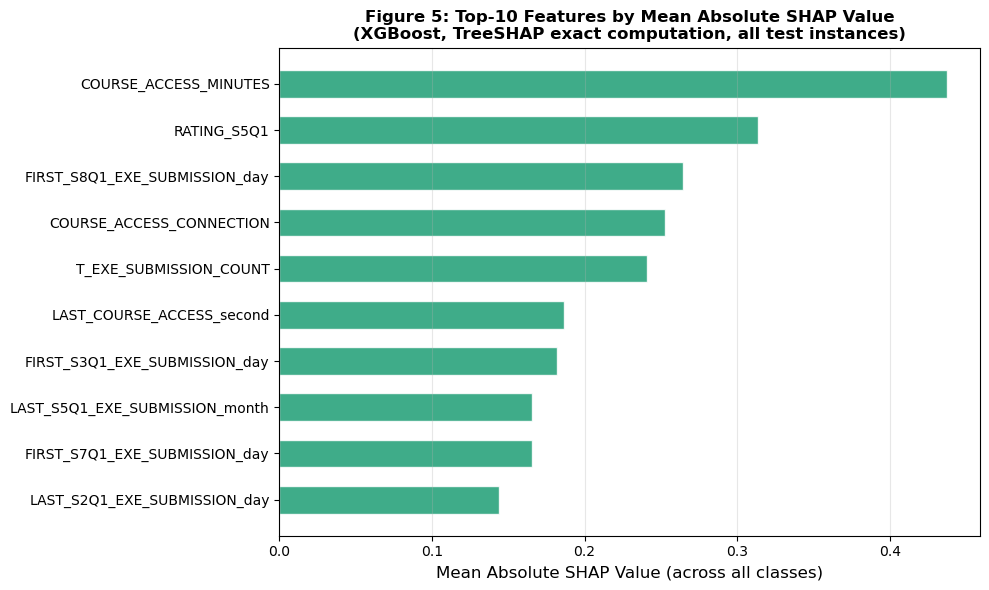

Saved: outputs/canva/fig5_shap_summary_xgb.png


In [14]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
os.makedirs('outputs/canva', exist_ok=True)

#  Fig: SHAP summary plot (XGBoost) ─────────────────────
model_name  = 'XGBoost'
model       = evaluator.trained_models[model_name]
X_test_vals = evaluator.X_test

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_vals)

# For multi-class: shap_values is a list of arrays (one per class)
# Use all classes stacked for global importance
if isinstance(shap_values, list):
    shap_all = np.abs(np.array(shap_values)).mean(axis=0)
else:
    shap_all = np.abs(shap_values)

mean_abs_shap = pd.Series(
    shap_all.mean(axis=0),
    index=evaluator.feature_names
).sort_values(ascending=True).tail(10)

labels = [f[:30] + '...' if len(f) > 30 else f for f in mean_abs_shap.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(mean_abs_shap)), mean_abs_shap.values,
        color='#1D9E75', alpha=0.85, edgecolor='white', height=0.6)
ax.set_yticks(range(len(mean_abs_shap)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Mean Absolute SHAP Value (across all classes)', fontsize=12)
ax.set_title('Figure 5: Top-10 Features by Mean Absolute SHAP Value\n'
             '(XGBoost, TreeSHAP exact computation, all test instances)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/canva/fig5_shap_summary_xgb.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: outputs/canva/fig5_shap_summary_xgb.png')

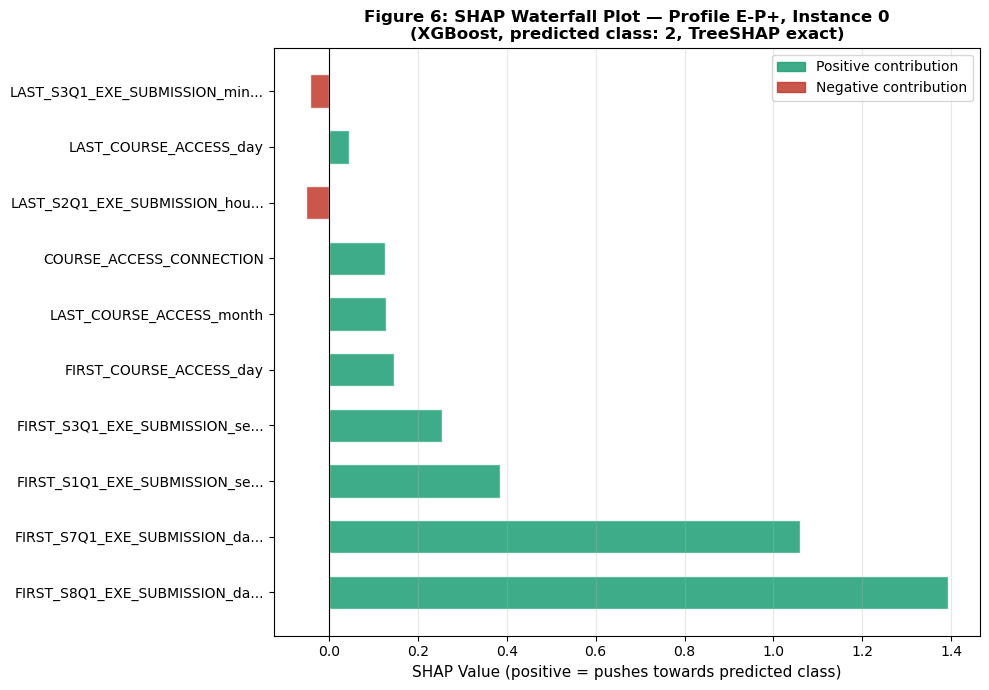

Saved: outputs/canva/fig6_shap_waterfall_empm_inst0.png


In [16]:
#Fig.: SHAP waterfall plot — E-P+ instance 0 (XGBoost) ─
# Instance 0 is an E-P+ student (disengaged but high-performing)

instance_idx = 0   # position in X_test corresponding to instance_id=0
profile_name = 'E-P+'

# Get the predicted class index for this instance
pred_class = int(model.predict(X_test_vals.iloc[[instance_idx]])[0])

# Select SHAP values for the predicted class
if isinstance(shap_values, list):
    sv_instance = shap_values[pred_class][instance_idx]
    base_value  = explainer.expected_value[pred_class]
else:
    sv_instance = shap_values[instance_idx]
    base_value  = explainer.expected_value

# Build a ranked feature table for the waterfall
feature_names = evaluator.feature_names
sv_series = pd.Series(sv_instance, index=feature_names)
top_n      = 10
sv_top       = sv_series.reindex(sv_series.abs().sort_values(ascending=False).index).head(top_n)

colors_wf = ['#1D9E75' if v > 0 else '#C0392B' for v in sv_top.values]
labels_wf  = [f[:28] + '...' if len(f) > 28 else f for f in sv_top.index]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(sv_top)), sv_top.values,
        color=colors_wf, alpha=0.85, edgecolor='white', height=0.6)
ax.set_yticks(range(len(sv_top)))
ax.set_yticklabels(labels_wf, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP Value (positive = pushes towards predicted class)', fontsize=11)
ax.set_title(f'Figure 6: SHAP Waterfall Plot — Profile {profile_name}, Instance 0\n'
              f'(XGBoost, predicted class: {pred_class}, TreeSHAP exact)',
              fontsize=12, fontweight='bold')

# Legend
import matplotlib.patches as mpatches
pos_patch = mpatches.Patch(color='#1D9E75', alpha=0.85, label='Positive contribution')
neg_patch = mpatches.Patch(color='#C0392B', alpha=0.85, label='Negative contribution')
ax.legend(handles=[pos_patch, neg_patch], fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/canva/fig6_shap_waterfall_empm_inst0.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: outputs/canva/fig6_shap_waterfall_empm_inst0.png')